In [2]:
# Step 2: EEG decoding


# GAO decoding analysis
# 
import pandas as pd
import glob
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
# from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import f1_score, roc_auc_score
import scipy.stats as stats
from scipy.interpolate import interp1d
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from joblib import Parallel, delayed
from sklearn.base import clone
from mne.time_frequency import tfr_array_morlet
import pingouin as pg

from utils.gao_functions import red_color, blue_color, red_palette, blue_palette, purple_color, purple_palette, lightblue_color, lightred_color, lightblue_palette, lightred_palette, calculate_vtc, calculate_BF, plot_BF_subplot, get_image_cat, make_timecourse_plot

# sm = SMOTE(random_state=42)
# X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# import numpy as np
# from scipy.io import loadmat
# import pandas as pd
import os
os.environ["R_HOME"] = r"/Library/Frameworks/R.framework/Resources"

from rpy2.robjects import r
import rpy2.robjects as ro
from rpy2.robjects.packages import importr
from rpy2.robjects import pandas2ri, numpy2ri
from rpy2.robjects.conversion import localconverter
import matplotlib.pyplot as plt
import seaborn as sns

bf_package=importr('BayesFactor')


# rus = RandomUnderSampler(random_state=42)

import matplotlib.pyplot as plt
from matplotlib import colors

import mne
# from mne.datasets import sample
from mne.decoding import (
    SlidingEstimator
)

# clf = make_pipeline(StandardScaler(), LogisticRegression(class_weight='balanced'), )

clf = make_pipeline(StandardScaler(), LinearDiscriminantAnalysis(store_covariance=True))
experiment_name = 'GAO'


from included_subs import subs

# CHECK UD/LR MAPPING _ DO NAMES MATCH NUMBERS?
dot_direction_map = {'UD':41, 'LR':42}
cat_map = {'vehicle':31, 'food': 32}

train_image_triggers = [11, 12] #vehicle, food
train_gabor_triggers = [21, 22] #Vertical, horizontal

test_image_triggers = [31, 32]# vehicle, food
test_gabor_triggers = [41, 42]# Vertical, horizontal

# smooth_VTC = 'yes'
# if smooth_VTC == 'yes':
#     vtc_variable = 'vtc_smooth_detrended'
# elif smooth_VTC == 'no':
#     vtc_variable = 'vtc_detrended'
# else:
#     print('smooth_VTC must be either yes or no!')
font_sz = 18
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['xtick.labelsize'] = font_sz
plt.rcParams['ytick.labelsize'] = font_sz
plt.rcParams['axes.titlesize'] = font_sz
plt.rcParams['legend.fontsize'] = font_sz - 4

figdir = '/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/output/figures/'

exclude_ppt_channels = 'yes'
exclude_channels = {
    '01':['TP9','Fp1','Fp2','P3'],
    '02':['CP6','T7','TP9','Fp1','Fp2'],
    '03':['F4','TP9','Fp1','Fp2'],
    '04':['TP9','Fp1','Fp2'],
    '05':['FC5','TP9','Fp1','Fp2'],
    '06':['TP9','Fp1','Fp2'],
    '07':['TP9','Fp1','Fp2'],
    '08':['T8', 'CP2', 'FT9', 'T7', 'TP9','Fp1','Fp2'],
    '09':['TP9','Fp1','Fp2'],
    '10':['T8', 'TP9','Fp1','Fp2'],
    '11':['C3', 'TP9','Fp1','Fp2'],
    '12':['TP9','Fp1','Fp2'],
    '13':['TP9','Fp1','Fp2'],
    '14':['T7','T8','FC2','P7','Cz','CP2', 'TP9','Fp1','Fp2'],
    '15':['TP9','Fp1','Fp2'],
    '16':['TP9','Fp1','Fp2'],
    '17':['TP9','Fp1','Fp2','T7','T8'],
    '18':['TP9','Fp1','Fp2','C4','FC1'],
    '19':['TP9','Fp1','Fp2','FT10','FT9','T7','FC6'],
    '20':['TP9','Fp1','Fp2'],
    '21':['TP9','Fp1','Fp2','F3','F4','T7'],
    '22':['TP9','Fp1','Fp2','FT10'],
    '23':['TP9','Fp1','Fp2'],
    '24':['TP9','Fp1','Fp2','FT10'],
    '25':['TP9','Fp1','Fp2','T7'],
    '26':['TP9','Fp1','Fp2'],
    '27':['TP9','Fp1','Fp2'],
    '28':['TP9','Fp1','Fp2','F3'],
    '29':['TP9','Fp1','Fp2','T8']
}



In [3]:

from collections import defaultdict
# For aligning decoding with response times 

def train_test_classifier(x_train, y_train, x_test_dict, y_test_dict, y_image_dict, analysis_list, sub, epochs):

    # X_binned, y_binned = average_epochs_in_bins(x_train, y_train, bin_size=10)
    # print('Starting training')
    time_decod = SlidingEstimator(clf, n_jobs=None, scoring="roc_auc", verbose=True)
    time_decod.fit(x_train, y_train)
    
    # y_predictions = time_decod_image.predict(x_test)
    results_dict = defaultdict()
    for analysis in analysis_list:
        print(analysis  + ' RUNNING')
        x_test = x_test_dict[analysis]
        y_test = y_test_dict[analysis]
        y_pproba = time_decod.predict_proba(x_test)
        pd.DataFrame(y_pproba[:,:,0]).to_csv('/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/output/timecourse_decoding/' + str(sub) + '_' + str(analysis) + '_pproba_EEG_check.csv', index=None, header=None)
        y_decision = time_decod.decision_function(x_test)
        print(y_pproba.shape)
        auc = [roc_auc_score(y_test, y_pproba[:,col,1]) for col in np.arange(0,y_pproba.shape[1])]
        results_dict[analysis] = auc
        pd.DataFrame(auc).to_csv('/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/output/timecourse_decoding/' + str(sub) + '_' + str(analysis) + '_AUC_check.csv', index=None, header=None)



    # SAVE predicted probabilities for memory models later
        if analysis == 'image_relevant':
            image_labs_veh = y_image_dict[analysis]['image_x'][y_test==31]
            pred_prob_veh = y_pproba[:,:,0][y_test==31]
            avg_pred_prob_veh = np.mean(pred_prob_veh[:,epochs.times>0], axis=1)
            avg_pred_prob_veh_late = np.mean(pred_prob_veh[:,epochs.times>0.3], axis=1)

            image_labs_food = y_image_dict[analysis]['image_x'][y_test==32]
            pred_prob_food = y_pproba[:,:,1][y_test==32]
            avg_pred_prob_food  = np.mean(pred_prob_food[:,epochs.times>0], axis=1)
            avg_pred_prob_food_late  = np.mean(pred_prob_food[:,epochs.times>0.3], axis=1)

            veh_DF = pd.concat([image_labs_veh.reset_index(), pd.DataFrame(pred_prob_veh)],axis=1)
            veh_DF['relevance'] = 'rel'
            veh_DF['average_prediction'] = avg_pred_prob_veh
            veh_DF['average_prediction_late'] = avg_pred_prob_veh_late

            food_DF = pd.concat([image_labs_food.reset_index(), pd.DataFrame(pred_prob_food)],axis=1)
            food_DF['relevance'] = 'rel'
            food_DF['average_prediction'] = avg_pred_prob_food
            food_DF['average_prediction_late'] = avg_pred_prob_food_late
            mem_out_DF = pd.concat([veh_DF, food_DF], axis=0)
            print(mem_out_DF.to_csv(f'/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/output/image_predicted_prob/{sub}_relevant_image_predicted_probs_parallelized_check.csv', index=False))


        if analysis == 'image_irrelevant':
            image_labs_veh_irrel = y_image_dict[analysis]['image_x'][y_test==31]
            pred_prob_veh_irrel = y_pproba[:,:,0][y_test==31]
            avg_pred_prob_veh_irrel = np.mean(pred_prob_veh_irrel[:,epochs.times>0], axis=1)
            avg_pred_prob_veh_irrel_late = np.mean(pred_prob_veh_irrel[:,epochs.times>0.3], axis=1)

            image_labs_food_irrel = y_image_dict[analysis]['image_x'][y_test==32]
            pred_prob_food_irrel = y_pproba[:,:,1][y_test==32]
            avg_pred_prob_food_irrel = np.mean(pred_prob_food_irrel[:,epochs.times>0], axis=1)
            avg_pred_prob_food_irrel_late = np.mean(pred_prob_food_irrel[:,epochs.times>0.3], axis=1)

            veh_DF_irrel = pd.concat([image_labs_veh_irrel.reset_index(), pd.DataFrame(pred_prob_veh_irrel)],axis=1)
            veh_DF_irrel['relevance'] = 'irrel'
            veh_DF_irrel['average_prediction'] = avg_pred_prob_veh_irrel
            veh_DF_irrel['average_prediction_late'] = avg_pred_prob_veh_irrel_late

            food_DF_irrel = pd.concat([image_labs_food_irrel.reset_index(), pd.DataFrame(pred_prob_food_irrel)],axis=1)
            food_DF_irrel['relevance'] = 'irrel'
            food_DF_irrel['average_prediction'] = avg_pred_prob_food_irrel
            food_DF_irrel['average_prediction_late'] = avg_pred_prob_food_irrel_late
            mem_out_DF = pd.concat([veh_DF_irrel, food_DF_irrel], axis=0)
            print(mem_out_DF.to_csv(f'/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/output/image_predicted_prob/{sub}_irrelevant_image_predicted_probs_parallelized_check.csv', index=False))


        # Save average RTs for violin plot 
        rts = y_image_dict[analysis]['rt_x']
        # print(rts)
        pd.DataFrame(rts).to_csv(f'/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/output/image_predicted_prob/{sub}_{analysis}_raw_rts_check.csv', header=None, index=None)


        # mem_out_DF = pd.concat([veh_DF, food_DF, veh_DF_irrel, food_DF_irrel], axis=0)
        # print(mem_out_DF.to_csv(f'/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_predicted_prob/{sub}_image_predicted_probs_parallelized.csv', index=False))

    return results_dict
    


def repeated_parallel_classification(x_train, y_train, x_test_dict, y_test_dict, y_image_dict, analysis_list, sub, epochs, n_jobs=-1):
    """
    Run classification multiple times in parallel and average predictions.
    """
    results = Parallel(n_jobs=n_jobs)(
        delayed(train_test_classifier)(x_train, y_train, x_test_dict, y_test_dict, y_image_dict, analysis_list, sub, epochs)
        for i in range(1)
    )


In [4]:
FWHM = 4
# subs = ['23','24','25','26','27','28','29']
for sub in subs:
    behav_dir = '/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/data/raw_data/raw_behavioral/' + sub + '/'
    # eeg_dir = '/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/data/preprocessed_data/derivatives/sub-' + sub + '/eeg/'
    # behav_dir = '/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/data/raw_data/raw_behavioral/' + sub + '/'
    eeg_dir ='/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/data/preprocessed_data/derivatives/sub-' + sub + '/eeg/'

    behav_files = glob.glob(behav_dir + sub + '*.csv')
    print(behav_files)
    if len(behav_files)==1:
        behav_file = pd.read_csv(behav_files[0])
    else:
        print('Multiple (or zero) behavioral files found for subject ' + sub)

    behav_file = behav_file[behav_file['task'].notna()]
    behav_file = behav_file[~behav_file['task'].str.contains('practice')]
    dot_training_trials = behav_file[behav_file['task']=='train_dots']
    cat_training_trials = behav_file[behav_file['task']=='train_image_cat']

    cpt_trials = behav_file[behav_file['task'].str.contains('cpt')]

    # print(cpt_trials.task)
    cpt_trials_vtc = calculate_vtc(cpt_trials, FWHM)

    behav_join_DF = pd.merge(behav_file, cpt_trials_vtc, left_index=True, right_index=True, how='outer')
    # behav_join_DF.to_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/data/behavioral_data_withVTC/' + sub + '/' + sub + '_behav_DF_withVTC.csv')
    # cpt_trials_vtc.to_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/data/behavioral_data_withVTC/' + sub + '/' + sub + '_CPT_DF_withVTC.csv')


    # Compare performance in and out of the zone
    in_zone = cpt_trials_vtc[(cpt_trials_vtc['vtc_smooth_detrended']<cpt_trials_vtc['vtc_smooth_median_detrended']) & (cpt_trials_vtc['correct_response']==0)]
    out_zone = cpt_trials_vtc[(cpt_trials_vtc['vtc_smooth_detrended']>cpt_trials_vtc['vtc_smooth_median_detrended']) & (cpt_trials_vtc['correct_response']==0)]

    in_acc = np.mean(in_zone['accuracy'])
    print('in the zone by VTC ' + str(in_acc))
    out_acc = np.mean(out_zone['accuracy'])
    print('out of the zone by VTC ' + str(out_acc))


    in_zone_RT = cpt_trials_vtc[(cpt_trials_vtc['detrended_RT']>cpt_trials_vtc['median_detrended_RT'])]
    out_zone_RT = cpt_trials_vtc[(cpt_trials_vtc['detrended_RT']<cpt_trials_vtc['median_detrended_RT'])]

    in_acc_RT = np.nanmean(in_zone_RT['accuracy'])
    print('in the zone by RT ' + str(in_acc_RT))
    out_acc_RT = np.nanmean(out_zone_RT['accuracy'])
    print('out of the zone by RT ' + str(out_acc_RT))

    # Load preprocessed EEG data--remove artifacts
    epochs_pre = mne.read_epochs(eeg_dir + 'sub-' + sub + '_task-GAO_desc-preprocessed_eeg.fif')
    epochs=epochs_pre.copy().resample(200, npad='auto')
    # epochs_resampled = epochs.copy().resample(100, npad='auto')
    events = pd.read_csv(eeg_dir + 'sub-' + sub + '_task-GAO_desc-preprocessed_events.tsv', header=0, sep='\t')
    # Drop TP9
    if exclude_ppt_channels == 'yes':
        epochs.drop_channels(exclude_channels[sub])
    else:
        epochs.drop_channels(['TP9','Fp1','Fp2'])

    artifacts = np.load(eeg_dir + 'sub-' + sub + '_task-GAO_desc-preprocessed_rejection_flags.npy')
    print(artifacts)

    epochs.drop(artifacts)
    events = events[~artifacts]


    behav_plusmem = behav_join_DF.copy()
    behav_join_DF = behav_join_DF[~behav_join_DF['task_x'].str.contains('memory')]
    behav_join_DF = behav_join_DF.reset_index(drop=True)
    behav_join_DF = behav_join_DF[~artifacts]


    x_data = epochs.get_data(picks='eeg')

    x_data_eyegaze = epochs.get_data(picks=['eyegaze'])
    x_data_pupil = epochs.get_data(picks=['pupil'])
    x_data_eog = epochs.get_data(picks=['eog'])

    # Get labeled trials
    x_train_image = x_data[events.value.isin(train_image_triggers)]
    x_test_image = x_data[events.value.isin(test_image_triggers)]
    x_train_gabor = x_data[events.value.isin(train_gabor_triggers)]
    x_test_gabor = x_data[events.value.isin(test_gabor_triggers)]

    y_train_image = events[events.value.isin(train_image_triggers)].value
    y_test_image = events[events.value.isin(test_image_triggers)].value
    y_train_gabor = events[events.value.isin(train_gabor_triggers)].value
    y_test_gabor = events[events.value.isin(test_gabor_triggers)].value

    included_trials_test_image = np.in1d(events['value'], test_image_triggers)
    included_trials_test_gabor = np.in1d(events['value'], test_gabor_triggers)

    behav_join_DF['image_cat'] = behav_join_DF['image_x'].apply(get_image_cat)
    behav_join_DF['cat_numeric'] = behav_join_DF['image_cat'].map(cat_map)
    behav_join_DF['direction_numeric'] = behav_join_DF['direction_x'].map(dot_direction_map)

    behav_test_image = behav_join_DF[included_trials_test_image]
    behav_test_image_irrel = behav_join_DF[included_trials_test_gabor]

    print(str(np.sum(y_train_image==11) + np.sum(y_train_image==12)) + ' training images')


    # Unsmoothed VTC
    x_test_image_inzone_VTC_unsmooth = x_test_image[behav_test_image["vtc_detrended"]<behav_test_image['vtc_median_detrended']]
    x_test_image_outzone_VTC_unsmooth = x_test_image[behav_test_image["vtc_detrended"]>behav_test_image['vtc_median_detrended']]
    behav_test_image_inzone_VTC_unsmooth = behav_test_image[behav_test_image["vtc_detrended"]<behav_test_image['vtc_median_detrended']]
    behav_test_image_outzone_VTC_unsmooth = behav_test_image[behav_test_image["vtc_detrended"]>behav_test_image['vtc_median_detrended']]

    # Use more extreme values of zone -- quartile
    x_test_image_inzone_VTC_unsmooth_quartile = x_test_image[behav_test_image["vtc_detrended"]<behav_test_image['vtc_lower_quartile_detrended']]
    x_test_image_outzone_VTC_unsmooth_quartile = x_test_image[behav_test_image["vtc_detrended"]>behav_test_image['vtc_upper_quartile_detrended']]
    behav_test_image_inzone_VTC_unsmooth_quartile = behav_test_image[behav_test_image["vtc_detrended"]<behav_test_image['vtc_lower_quartile_detrended']]
    behav_test_image_outzone_VTC_unsmooth_quartile = behav_test_image[behav_test_image["vtc_detrended"]>behav_test_image['vtc_upper_quartile_detrended']]



    x_test_image_inzone_RT = x_test_image[behav_test_image['detrended_RT']>behav_test_image['median_detrended_RT']]
    x_test_image_outzone_RT = x_test_image[behav_test_image['detrended_RT']<behav_test_image['median_detrended_RT']]
    behav_test_image_inzone_RT = behav_test_image[behav_test_image['detrended_RT']>behav_test_image['median_detrended_RT']]
    behav_test_image_outzone_RT = behav_test_image[behav_test_image['detrended_RT']<behav_test_image['median_detrended_RT']]


    x_test_image_inzone_RT_quartile = x_test_image[behav_test_image['detrended_RT']>behav_test_image['RT_upper_quartile']]
    x_test_image_outzone_RT_quartile = x_test_image[behav_test_image['detrended_RT']<behav_test_image['RT_lower_quartile']]
    behav_test_image_inzone_RT_quartile = behav_test_image[behav_test_image['detrended_RT']>behav_test_image['RT_upper_quartile']]
    behav_test_image_outzone_RT_quartile = behav_test_image[behav_test_image['detrended_RT']<behav_test_image['RT_lower_quartile']]

    # print(x_test_image_inzone_RT_quartile)

    behav_test_gabor = behav_join_DF[included_trials_test_gabor]
    behav_test_gabor['image_cat'] = behav_test_gabor['image_x'].apply(get_image_cat)
    behav_test_gabor['cat_numeric'] = behav_test_gabor['image_cat'].map(cat_map)
    behav_test_gabor['direction_numeric'] = behav_test_gabor['direction_x'].map(dot_direction_map)

# sub_run_df["vtc_smooth_detrended"]>sub_run_df['vtc_smooth_median_detrended']
    # x_test_gabor_inzone_VTC = x_test_gabor[behav_test_gabor["vtc_smooth_detrended"]<behav_test_gabor['vtc_smooth_median_detrended']]
    # x_test_gabor_outzone_VTC = x_test_gabor[behav_test_gabor["vtc_smooth_detrended"]>behav_test_gabor['vtc_smooth_median_detrended']]
    # behav_test_gabor_inzone_VTC = behav_test_gabor[behav_test_gabor["vtc_smooth_detrended"]<behav_test_gabor['vtc_smooth_median_detrended']]
    # behav_test_gabor_outzone_VTC = behav_test_gabor[behav_test_gabor["vtc_smooth_detrended"]>behav_test_gabor['vtc_smooth_median_detrended']]
  
    #Unsmoothed VTC
    x_test_gabor_inzone_VTC_unsmooth = x_test_gabor[behav_test_gabor["vtc_detrended"]<behav_test_gabor['vtc_median_detrended']]
    x_test_gabor_outzone_VTC_unsmooth = x_test_gabor[behav_test_gabor["vtc_detrended"]>behav_test_gabor['vtc_median_detrended']]
    behav_test_gabor_inzone_VTC_unsmooth = behav_test_gabor[behav_test_gabor["vtc_detrended"]<behav_test_gabor['vtc_median_detrended']]
    behav_test_gabor_outzone_VTC_unsmooth = behav_test_gabor[behav_test_gabor["vtc_detrended"]>behav_test_gabor['vtc_median_detrended']]

    x_test_gabor_inzone_RT = x_test_gabor[behav_test_gabor['detrended_RT']>behav_test_gabor['median_detrended_RT']]
    x_test_gabor_outzone_RT = x_test_gabor[behav_test_gabor['detrended_RT']<behav_test_gabor['median_detrended_RT']]
    behav_test_gabor_inzone_RT = behav_test_gabor[behav_test_gabor['detrended_RT']>behav_test_gabor['median_detrended_RT']]
    behav_test_gabor_outzone_RT = behav_test_gabor[behav_test_gabor['detrended_RT']<behav_test_gabor['median_detrended_RT']]

    x_test_gabor_inzone_RT_quartile = x_test_gabor[behav_test_gabor['detrended_RT']>behav_test_gabor['RT_upper_quartile']]
    x_test_gabor_outzone_RT_quartile = x_test_gabor[behav_test_gabor['detrended_RT']<behav_test_gabor['RT_lower_quartile']]
    behav_test_gabor_inzone_RT_quartile = behav_test_gabor[behav_test_gabor['detrended_RT']>behav_test_gabor['RT_upper_quartile']]
    behav_test_gabor_outzone_RT_quartile = behav_test_gabor[behav_test_gabor['detrended_RT']<behav_test_gabor['RT_lower_quartile']]

# Remove nans because some might be exactly equal to median

    # ## QUARTILE VTC
    # x_test_gabor_inzone_VTC_quartile = x_test_gabor[behav_test_gabor["vtc_smooth_detrended"]<behav_test_gabor['vtc_smooth_lower_quartile_detrended']]
    # x_test_gabor_outzone_VTC_quartile = x_test_gabor[behav_test_gabor["vtc_smooth_detrended"]>behav_test_gabor['vtc_smooth_upper_quartile_detrended']]
    # behav_test_gabor_inzone_VTC_quartile = behav_test_gabor[behav_test_gabor["vtc_smooth_detrended"]<behav_test_gabor['vtc_smooth_lower_quartile_detrended']]
    # behav_test_gabor_outzone_VTC_quartile = behav_test_gabor[behav_test_gabor["vtc_smooth_detrended"]>behav_test_gabor['vtc_smooth_upper_quartile_detrended']]
  
    # QUARTILE Unsmoothed VTC
    x_test_gabor_inzone_VTC_unsmooth_quartile = x_test_gabor[behav_test_gabor["vtc_detrended"]<behav_test_gabor['vtc_lower_quartile_detrended']]
    x_test_gabor_outzone_VTC_unsmooth_quartile = x_test_gabor[behav_test_gabor["vtc_detrended"]>behav_test_gabor['vtc_upper_quartile_detrended']]
    behav_test_gabor_inzone_VTC_unsmooth_quartile = behav_test_gabor[behav_test_gabor["vtc_detrended"]<behav_test_gabor['vtc_lower_quartile_detrended']]
    behav_test_gabor_outzone_VTC_unsmooth_quartile = behav_test_gabor[behav_test_gabor["vtc_detrended"]>behav_test_gabor['vtc_upper_quartile_detrended']]


########################################## IMAGE DECODING #########################################################


###### IMAGE DECODING
    analysis_list_image = ['image_relevant',
                     'image_irrelevant', 
                    #  'image_relevant_inzone_VTC_quartile',
                    #  'image_relevant_outzone_VTC_quartile',
                    #  'image_irrelevant_inzone_VTC_quartile',
                    #  'image_irrelevant_outzone_VTC_quartile',
                     'image_relevant_inzone_RT_quartile',
                     'image_relevant_outzone_RT_quartile',
                     'image_irrelevant_inzone_RT_quartile',
                     'image_irrelevant_outzone_RT_quartile'
                     ]


    test_x_image_dict = {
        'image_relevant': x_test_image,
        'image_irrelevant': x_test_gabor,
        # 'image_relevant_inzone_VTC_quartile': x_test_image_inzone_VTC_unsmooth_quartile,
        # 'image_relevant_outzone_VTC_quartile': x_test_image_outzone_VTC_unsmooth_quartile,
        # 'image_irrelevant_inzone_VTC_quartile': x_test_gabor_inzone_VTC_unsmooth_quartile,
        # 'image_irrelevant_outzone_VTC_quartile': x_test_gabor_outzone_VTC_unsmooth_quartile,
        'image_relevant_inzone_RT_quartile': x_test_image_inzone_RT_quartile,
        'image_relevant_outzone_RT_quartile': x_test_image_outzone_RT_quartile,
        'image_irrelevant_inzone_RT_quartile': x_test_gabor_inzone_RT_quartile,
        'image_irrelevant_outzone_RT_quartile': x_test_gabor_outzone_RT_quartile

    }

    test_y_image_dict={
        'image_relevant': y_test_image,
        'image_irrelevant': behav_test_gabor['cat_numeric'],
        # 'image_relevant_inzone_VTC_quartile': behav_test_image_inzone_VTC_unsmooth_quartile['cat_numeric'],
        # 'image_relevant_outzone_VTC_quartile': behav_test_image_outzone_VTC_unsmooth_quartile['cat_numeric'],
        # 'image_irrelevant_inzone_VTC_quartile': behav_test_gabor_inzone_VTC_unsmooth_quartile['cat_numeric'],
        # 'image_irrelevant_outzone_VTC_quartile': behav_test_gabor_outzone_VTC_unsmooth_quartile['cat_numeric'],
        'image_relevant_inzone_RT_quartile': behav_test_image_inzone_RT_quartile['cat_numeric'],
        'image_relevant_outzone_RT_quartile': behav_test_image_outzone_RT_quartile['cat_numeric'],
        'image_irrelevant_inzone_RT_quartile': behav_test_gabor_inzone_RT_quartile['cat_numeric'],
        'image_irrelevant_outzone_RT_quartile': behav_test_gabor_outzone_RT_quartile['cat_numeric']
    }

    Images_y_image_dict={
        'image_relevant': behav_test_image,
        'image_irrelevant': behav_test_gabor,
        # 'image_relevant_inzone_VTC_quartile': behav_test_image_inzone_VTC_unsmooth_quartile,
        # 'image_relevant_outzone_VTC_quartile': behav_test_image_outzone_VTC_unsmooth_quartile,
        # 'image_irrelevant_inzone_VTC_quartile': behav_test_gabor_inzone_VTC_unsmooth_quartile,
        # 'image_irrelevant_outzone_VTC_quartile': behav_test_gabor_outzone_VTC_unsmooth_quartile,
        'image_relevant_inzone_RT_quartile': behav_test_image_inzone_RT_quartile,
        'image_relevant_outzone_RT_quartile': behav_test_image_outzone_RT_quartile,
        'image_irrelevant_inzone_RT_quartile': behav_test_gabor_inzone_RT_quartile,
        'image_irrelevant_outzone_RT_quartile': behav_test_gabor_outzone_RT_quartile
    }

    
    analysis_list_gabor = [
                     'gabor_relevant',
                     'gabor_irrelevant', 
                    #  'gabor_relevant_inzone_VTC_quartile',
                    #  'gabor_relevant_outzone_VTC_quartile',
                    #  'gabor_irrelevant_inzone_VTC_quartile',
                    #  'gabor_irrelevant_outzone_VTC_quartile',
                     'gabor_relevant_inzone_RT_quartile',
                     'gabor_relevant_outzone_RT_quartile',
                     'gabor_irrelevant_inzone_RT_quartile',
                     'gabor_irrelevant_outzone_RT_quartile'  
                     ]
    
    test_x_gabor_dict = {
        'gabor_relevant':x_test_gabor,
        'gabor_irrelevant': x_test_image, 
        # 'gabor_relevant_inzone_VTC_quartile': x_test_gabor_inzone_VTC_unsmooth_quartile,
        # 'gabor_relevant_outzone_VTC_quartile': x_test_gabor_outzone_VTC_unsmooth_quartile,
        # 'gabor_irrelevant_inzone_VTC_quartile': x_test_image_inzone_VTC_unsmooth_quartile,
        # 'gabor_irrelevant_outzone_VTC_quartile': x_test_image_outzone_VTC_unsmooth_quartile,
        'gabor_relevant_inzone_RT_quartile': x_test_gabor_inzone_RT_quartile,
        'gabor_relevant_outzone_RT_quartile': x_test_gabor_outzone_RT_quartile,
        'gabor_irrelevant_inzone_RT_quartile': x_test_image_inzone_RT_quartile,
        'gabor_irrelevant_outzone_RT_quartile': x_test_image_outzone_RT_quartile
    }

    test_y_gabor_dict = {
        'gabor_relevant': y_test_gabor,
        'gabor_irrelevant': behav_test_image['direction_numeric'], 
        # 'gabor_relevant_inzone_VTC_quartile': behav_test_gabor_inzone_VTC_unsmooth_quartile['direction_numeric'],
        # 'gabor_relevant_outzone_VTC_quartile': behav_test_gabor_outzone_VTC_unsmooth_quartile['direction_numeric'],
        # 'gabor_irrelevant_inzone_VTC_quartile': behav_test_image_inzone_VTC_unsmooth_quartile['direction_numeric'],
        # 'gabor_irrelevant_outzone_VTC_quartile': behav_test_image_outzone_VTC_unsmooth_quartile['direction_numeric'],
        'gabor_relevant_inzone_RT_quartile': behav_test_gabor_inzone_RT_quartile['direction_numeric'],
        'gabor_relevant_outzone_RT_quartile': behav_test_gabor_outzone_RT_quartile['direction_numeric'],
        'gabor_irrelevant_inzone_RT_quartile': behav_test_image_inzone_RT_quartile['direction_numeric'],
        'gabor_irrelevant_outzone_RT_quartile': behav_test_image_outzone_RT_quartile['direction_numeric']

    }
    Images_y_gabor_dict = {
        'gabor_relevant': behav_test_gabor,
        'gabor_irrelevant': behav_test_image, 
        # 'gabor_relevant_inzone_VTC_quartile': behav_test_gabor_inzone_VTC_unsmooth_quartile,
        # 'gabor_relevant_outzone_VTC_quartile': behav_test_gabor_outzone_VTC_unsmooth_quartile,
        # 'gabor_irrelevant_inzone_VTC_quartile': behav_test_image_inzone_VTC_unsmooth_quartile,
        # 'gabor_irrelevant_outzone_VTC_quartile': behav_test_image_outzone_VTC_unsmooth_quartile,
        'gabor_relevant_inzone_RT_quartile': behav_test_gabor_inzone_RT_quartile,
        'gabor_relevant_outzone_RT_quartile': behav_test_gabor_outzone_RT_quartile,
        'gabor_irrelevant_inzone_RT_quartile': behav_test_image_inzone_RT_quartile,
        'gabor_irrelevant_outzone_RT_quartile': behav_test_image_outzone_RT_quartile
    }



    repeated_parallel_classification(x_train_image, y_train_image, test_x_image_dict, test_y_image_dict, Images_y_image_dict, analysis_list_image, sub, epochs, n_jobs=-1)
    # pd.DataFrame(avg_auc_image_relevant).to_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_decoding/' + sub + '_relevant_AUC_binned.csv', index=None, header=None)
    repeated_parallel_classification(x_train_gabor, y_train_gabor, test_x_gabor_dict, test_y_gabor_dict, Images_y_gabor_dict, analysis_list_gabor, sub, epochs, n_jobs=-1)
    # pd.DataFrame(avg_auc_image_relevant).to_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_decoding/' + sub + '_relevant_AUC_binned.csv', index=None, header=None)

    # Save predicted probabilities 
    # relevant_df = pd.read_csv(f'/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_predicted_prob/{sub}_relevant_image_predicted_probs_parallelized.csv', header=None)
    # irrelevant_df = pd.read_csv(f'/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_predicted_prob/{sub}_irrelevant_image_predicted_probs_parallelized.csv', header=None)
    # mem_df = pd.concat([relevant_df, irrelevant_df], axis=0)
    # mem_df.to_csv(f'/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_predicted_prob/{sub}_image_predicted_probs_parallelized.csv', header=False, index=False)

['/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/data/raw_data/raw_behavioral/01/01_data_2025_Oct_29_1041_5.csv']
0.05140345076172896
0.05909256401758137
0.05101376202245117
0.04883439089050293
in the zone by VTC 0.7235772357723578
out of the zone by VTC 0.6666666666666666
in the zone by RT 1.0
out of the zone by RT 1.0
Reading /Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/data/preprocessed_data/derivatives/sub-01/eeg/sub-01_task-GAO_desc-preprocessed_eeg.fif ...


/Users/annacorriveau/Documents/GitHub/FluxDecoding/clean_analysis_scripts/utils/gao_functions.py:56: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_run_df["detrended_RT"] = sub_run_df["rt"]-(intercept+slope*np.arange(len(sub_run_df))) #subtract linear trend
/Users/annacorriveau/Documents/GitHub/FluxDecoding/clean_analysis_scripts/utils/gao_functions.py:57: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_run_df["median_detrended_RT"] = np.nanmedian(sub_run_df["detrended_RT"])
/Users/annacorriveau/Docume

    Found the data of interest:
        t =    -150.00 ...     800.00 ms
        0 CTF compensation matrices available
Adding metadata with 12 columns
6000 matching events found
No baseline correction applied
0 projection items activated
[False False  True ... False  True False]
Dropped 2183 epochs: 2, 6, 7, 8, 9, 11, 15, 19, 20, 21, 22, 25, 28, 29, 31, 33, 35, 36, 38, 39, 40, 41, 42, 44, 46, 47, 49, 50, 54, 55, 57, 59, 60, 64, 65, 69, 73, 75, 77, 80, 84, 85, 89, 93, 96, 99, 101, 106, 108, 111, 113, 114, 118, 122, 125, 129, 130, 133, 136, 141, 142, 144, 147, 149, 151, 153, 156, 157, 158, 161, 165, 168, 170, 172, 173, 176, 177, 179, 181, 183, 186, 188, 191, 192, 194, 197, 200, 204, 205, 207, 208, 210, 213, 216, 219, 222, 228, 230, 233, 234, 235, 236, 239, 240, 241, 245, 246, 248, 251, 252, 255, 256, 260, 261, 262, 264, 266, 269, 271, 272, 273, 276, 279, 283, 285, 287, 290, 291, 293, 294, 295, 297, 298, 300, 301, 302, 303, 304, 305, 307, 310, 312, 314, 316, 318, 319, 321, 322, 324, 325, 

/var/folders/fd/rp0cg1pj0_1734s2_j8y5dxw0000gp/T/ipykernel_98257/1524922439.py:131: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  behav_test_gabor['image_cat'] = behav_test_gabor['image_x'].apply(get_image_cat)
/var/folders/fd/rp0cg1pj0_1734s2_j8y5dxw0000gp/T/ipykernel_98257/1524922439.py:132: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  behav_test_gabor['cat_numeric'] = behav_test_gabor['image_cat'].map(cat_map)
/var/folders/fd/rp0cg1pj0_1734s2_j8y5dxw0000gp/T/ipykernel_98257/1524922439.py:133: SettingWit

image_relevant RUNNING


...

(197, 190, 2)
gabor_irrelevant_inzone_RT_quartile RUNNING


100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1102.22it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1283.85it/s]


(194, 190, 2)
gabor_irrelevant_outzone_RT_quartile RUNNING


100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1260.64it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1259.68it/s]


(175, 190, 2)


/Users/annacorriveau/miniconda3/envs/gao_env/lib/python3.10/site-packages/rpy2/robjects/pandas2ri.py:56: UserWarning: DataFrame contains duplicated elements in the index, which will lead to loss of the row names in the resulting data.frame
  warnings.warn('DataFrame contains duplicated elements in the index, '


rel vs irrel paired t-test
               T  dof alternative     p-val         CI95%   cohen-d      BF10  \
T-test  5.798731   24   two-sided  0.000006  [0.02, 0.03]  1.161053  3671.504   

           power  
T-test  0.999841  
0.5537293413817111
0.022411402916653507
0.530139181854711
0.01703929620292293
rel above chance t-test, 1-sample
                T  dof alternative         p-val        CI95%   cohen-d  \
T-test  11.744867   24     greater  9.738110e-12  [0.55, inf]  2.348973   

             BF10  power  
T-test  9.133e+08    1.0  
Irrel above chance t-test, 1-sample
               T  dof alternative         p-val        CI95%   cohen-d  \
T-test  8.665336   24     greater  3.728981e-09  [0.52, inf]  1.733067   

            BF10  power  
T-test  3.39e+06    1.0  
               T  dof alternative     p-val         CI95%   cohen-d      BF10  \
T-test  5.798731   24   two-sided  0.000006  [0.02, 0.03]  1.161053  3671.504   

           power  
T-test  0.999841  
relevant
0.553729

/Users/annacorriveau/Documents/GitHub/FluxDecoding/clean_analysis_scripts/utils/gao_functions.py:313: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


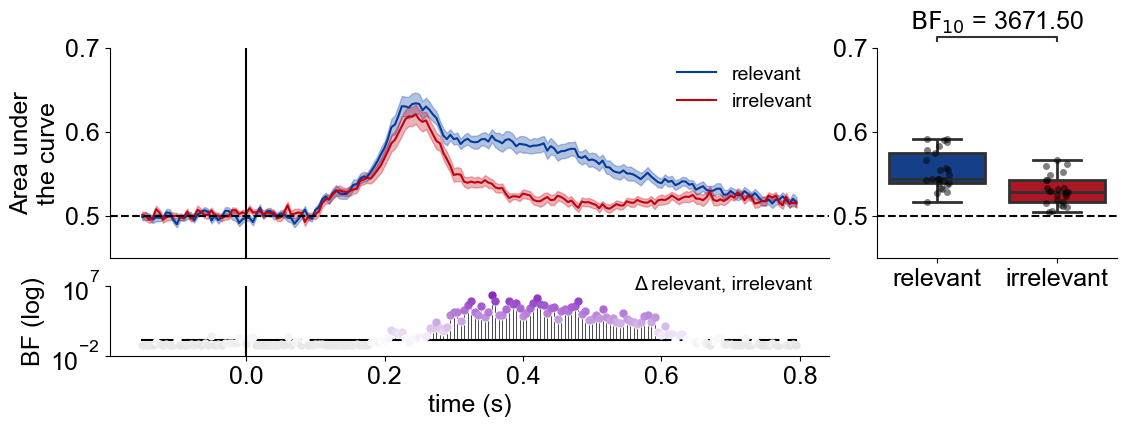

In [22]:

if 'epochs' not in vars():
    epochs_pre = mne.read_epochs('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/data/preprocessed_data/derivatives/sub-' + '01' + '/eeg/' + 'sub-' + '01' + '_task-GAO_desc-preprocessed_eeg.fif')
    epochs = epochs_pre.copy().resample(200)
x_axis = epochs.times

rel_acc_df = pd.DataFrame()
irrel_acc_df = pd.DataFrame()
kfold_df = pd.DataFrame()
# subs=['01','02','03','04','05','06','07','08','10','12','13','14','15','17','18','20','21','22','23','24','25','26','27','28','29']
rel_mean = []
irrel_mean = []
# subs=['01']
for s in subs:
    # k_fold = pd.read_csv(f'/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/localizer_crossval_decoding/{s}_image_decoding_timecourse.csv', header=None)
    # kfold_df = pd.concat([kfold_df, k_fold.T],axis=0)
    rel_acc = pd.read_csv('/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/output/timecourse_decoding/' + s + '_image_relevant_AUC_check.csv', header=None)
    # rel_acc = pd.read_csv('/Users/annacorriveau/Documents/GitHub/FluxDecoding/output/image_decoding/' + s + '_relevant_AUC.csv', header=None)
    rel_acc_df= pd.concat([rel_acc_df, rel_acc.T], axis=0)
    rel_mean.append(np.mean(rel_acc[epochs.times>0.0]))
    irrel_acc = pd.read_csv('/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/output/timecourse_decoding/' + s + '_image_irrelevant_AUC_check.csv', header=None)
    irrel_acc_df= pd.concat([irrel_acc_df, irrel_acc.T], axis=0)
    irrel_mean.append(np.mean(irrel_acc[epochs.times>0.0]))

mean_rel_acc = np.mean(rel_acc_df, axis=0)
mean_irrel_acc = np.mean(irrel_acc_df, axis=0)
mean_kfold = np.mean(kfold_df, axis=0)

SE_rel = stats.sem(rel_acc_df, axis=0)
SE_irrel = stats.sem(irrel_acc_df, axis=0)
SE_kfold = stats.sem(kfold_df, axis=0)



bf_diff = calculate_BF(rel_acc_df, irrel_acc_df)
# figname = figdir + 'Fig1_RelIrrel_BF.png'
# fig = plt.figure(figsize=(15, 6))

# gs = fig.add_gridspec(
#     nrows=2,
#     ncols=3,
#     width_ratios=[5, 1, 1],
#     height_ratios=[3, 1],
#     wspace=0.1,
#     hspace=0.4
# )

# # Left column
# ax_dec = fig.add_subplot(gs[0, 0])
# ax_bf = fig.add_subplot(gs[1, 0])

# # Right side of decoding plot
# ax_rel = fig.add_subplot(gs[0, 1], sharey=ax_dec)
# ax_irrel = fig.add_subplot(gs[0, 2], sharey=ax_dec)




# # fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(8, 6), gridspec_kw={'wspace': 0.4, 'hspace': 0.4, 'height_ratios': [3, 1]})
# ax_dec.plot(x_axis, mean_rel_acc, color='#033A9C', label="relevant")
# ax_dec.fill_between(x_axis, mean_rel_acc - SE_rel, mean_rel_acc + SE_rel, color=blue_color, alpha=0.3)

# ax_dec.plot(x_axis, mean_irrel_acc, red_color, label="irrelevant")
# ax_dec.fill_between(x_axis, mean_irrel_acc - SE_irrel, mean_irrel_acc + SE_irrel, color=red_color, alpha=0.3)
# ax_dec.set_ylim(0.45, 0.7)
# ax_dec.set_yticks([0.5, 0.6, 0.7])
# ax.plot(test_epochs.times, mean_y_pred_vehicle, label="score")
# ax[0].get_xaxis().get_major_formatter().labelOnlyBase = True
# ax.axvline(0.0, color="k", linestyle="-")

# ax_dec.spines['right'].set_visible(False)
# ax_dec.spines['top'].set_visible(False)
# ax_dec.axhline(0.5, color="k", linestyle="--")
# ax_dec.set_ylabel("Area under\nthe curve", fontsize=font_sz)  # Area Under the Curve
# ax_dec.legend(frameon=False, framealpha=0)
# ax_dec.axvline(0.0, color="k", linestyle="-")
# ax_dec.set_title("Image category decoding", fontsize=font_sz)
# ax_dec.set_xticks([])


# # fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(8, 6), sharey=True)
# # sns.violinplot(rel_mean, cut=0, color=blue_color, linewidth=0, ax=ax[0])
# sns.boxplot(rel_mean, color=blue_color, linewidth=2, fliersize=0, ax=ax_rel)
# sns.stripplot(rel_mean, color="black", alpha=0.5, ax=ax_rel)
# ax_rel.scatter(0,np.mean(rel_mean), color='white')
# ax_rel.set_xticklabels({'relevant'})

# # sns.violinplot(irrel_mean, cut=0, color=red_color,linewidth=0, ax=ax[1])
# sns.boxplot(irrel_mean, color=red_color,linewidth=2, ax=ax_irrel)
# sns.stripplot(irrel_mean, color="black", alpha=0.5, ax=ax_irrel)
# ax_irrel.scatter(0,np.mean(irrel_mean), color='white')
# ax_irrel.set_xticklabels({'irrelevant'})
# ax_irrel.tick_params(left=False)
# # ax_irrel.set_yticks([])
# sns.despine(right=True)

# # ax_rel.tick_params(axis='y', left=False, labelleft=False)
# ax_irrel.tick_params(axis='y', left=False, labelleft=False)

# plot_BF_subplot(x_axis, bf_diff, purple_palette, ax=ax_bf, title="\u0394 relevant, irrelevant", topLim=7, bottomLim=2, xlabel=True)
# # plt.show()
# plt.savefig(figdir + 'Fig2A_image_relirrel_onsetlocked.png', bbox_inches='tight')
# plt.show()

print('rel vs irrel paired t-test')
print(pg.ttest(rel_mean, irrel_mean, paired=True))
print(np.mean(rel_mean))
print(np.std(rel_mean))
print(np.mean(irrel_mean))
print(np.std(irrel_mean))

print('rel above chance t-test, 1-sample')
print(pg.ttest(rel_mean, 0.5, alternative='greater'))

print('Irrel above chance t-test, 1-sample')
print(pg.ttest(irrel_mean, 0.5, alternative='greater'))

plot_dict_rel = {
    'tc1': mean_rel_acc, 
    'tc1_label': "relevant",
    'tc2': mean_irrel_acc,
    'tc2_label': "irrelevant",
    'tc1_SE': SE_rel,
    'tc2_SE': SE_irrel,
    'tc1_color': blue_color,
    'tc2_color': red_color,
    'tc2_linestyle':'-',
    'bar1': rel_mean,
    'bar1_label': 'relevant',
    'bar2_label': 'irrelevant',
    'bar2': irrel_mean,
    'BF': bf_diff,
    'BF_palette': purple_palette,
    'BF_title':"\u0394 relevant, irrelevant",
    'BF_top':7,
    'x_axis': epochs.times,
    'save_name':figdir + 'Fig2A_image_onsetlocked_check.png'
}

make_timecourse_plot(plot_dict_rel)



/Users/annacorriveau/miniconda3/envs/gao_env/lib/python3.10/site-packages/rpy2/robjects/pandas2ri.py:56: UserWarning: DataFrame contains duplicated elements in the index, which will lead to loss of the row names in the resulting data.frame
  warnings.warn('DataFrame contains duplicated elements in the index, '


               T  dof alternative     p-val        CI95%   cohen-d BF10  \
T-test  2.877476   24   two-sided  0.008287  [0.0, 0.01]  0.734954  5.6   

           power  
T-test  0.941112  
0.5122235732632352
0.008932143480948783
0.5055884492808672
0.008758093764155603
rel above chance t-test, 1-sample
               T  dof alternative         p-val        CI95%   cohen-d  \
T-test  6.704218   24     greater  3.097723e-07  [0.51, inf]  1.340844   

             BF10     power  
T-test  5.558e+04  0.999999  
Irrel above chance t-test, 1-sample
               T  dof alternative     p-val       CI95%   cohen-d    BF10  \
T-test  3.125988   24     greater  0.002296  [0.5, inf]  0.625198  18.508   

           power  
T-test  0.917911  
               T  dof alternative     p-val        CI95%   cohen-d BF10  \
T-test  2.877476   24   two-sided  0.008287  [0.0, 0.01]  0.734954  5.6   

           power  
T-test  0.941112  
relevant
0.5122235732632352
0.008932143480948783
irrelevant
0.50558844

/Users/annacorriveau/Documents/GitHub/FluxDecoding/clean_analysis_scripts/utils/gao_functions.py:313: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


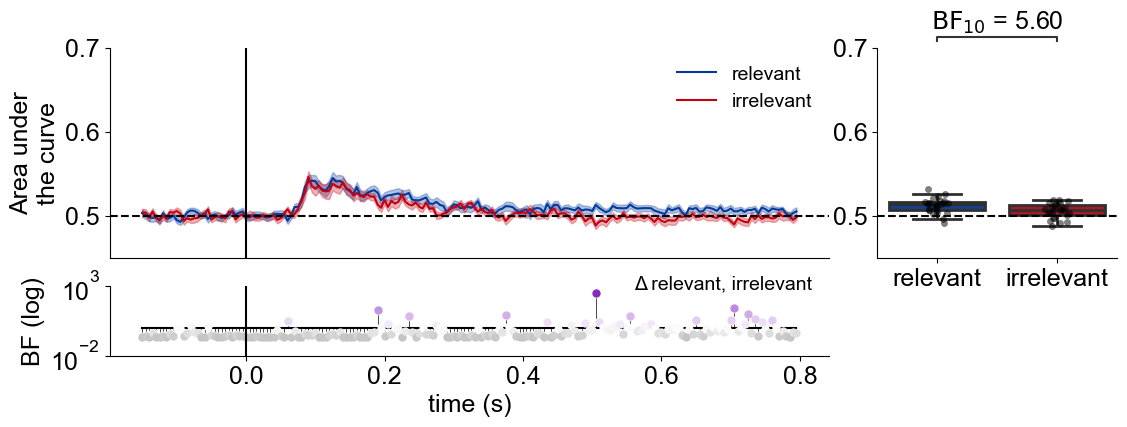

In [25]:
# clf = make_pipeline(StandardScaler(), LogisticRegression(solver="liblinear"))
rel_acc_df = pd.DataFrame()
irrel_acc_df = pd.DataFrame()
kfold_df = pd.DataFrame()
rel_mean = []
irrel_mean = []
# subs=['01','02','03','04','05','06','07','08','09','10','11','12','13','14']
for s in subs:
    # k_fold = pd.read_csv(f'/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/localizer_crossval_decoding/{s}_gabor_decoding_timecourse.csv', header=None)
    # kfold_df = pd.concat([kfold_df, k_fold.T],axis=0)
    rel_acc = pd.read_csv('/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/output/timecourse_decoding/' + s + '_gabor_relevant_AUC_check.csv', header=None)
    rel_acc_df= pd.concat([rel_acc_df, rel_acc.T], axis=0)
    rel_mean.append(np.mean(rel_acc[epochs.times>0.0]))
    irrel_acc = pd.read_csv('/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/output/timecourse_decoding/' + s + '_gabor_irrelevant_AUC_check.csv', header=None)
    irrel_acc_df= pd.concat([irrel_acc_df, irrel_acc.T], axis=0)
    irrel_mean.append(np.mean(irrel_acc[epochs.times>0.0]))

mean_rel_acc = np.mean(rel_acc_df, axis=0)
mean_irrel_acc = np.mean(irrel_acc_df, axis=0)
mean_kfold = np.mean(kfold_df, axis=0)

SE_rel = stats.sem(rel_acc_df, axis=0)
SE_irrel = stats.sem(irrel_acc_df, axis=0)
SE_kfold = stats.sem(kfold_df, axis=0)



bf_diff = calculate_BF(rel_acc_df, irrel_acc_df)


print(pg.ttest(rel_mean, irrel_mean, paired=True))
print(np.mean(rel_mean))
print(np.std(rel_mean))
print(np.mean(irrel_mean))
print(np.std(irrel_mean))
# figname = figdir + 'Fig1_RelIrrel_BF.png'
#
print('rel above chance t-test, 1-sample')
print(pg.ttest(rel_mean, 0.5, alternative='greater'))

print('Irrel above chance t-test, 1-sample')
print(pg.ttest(irrel_mean, 0.5, alternative='greater'))

plot_dict_rel = {
    'tc1': mean_rel_acc, 
    'tc1_label': "relevant",
    'tc2': mean_irrel_acc,
    'tc2_label': "irrelevant",
    'tc1_SE': SE_rel,
    'tc2_SE': SE_irrel,
    'tc1_color': blue_color,
    'tc2_color': red_color,
    'tc2_linestyle':'-',
    'bar1': rel_mean,
    'bar1_label': 'relevant',
    'bar2_label': 'irrelevant',
    'bar2': irrel_mean,
    'BF': bf_diff,
    'BF_palette': purple_palette,
    'BF_title':"\u0394 relevant, irrelevant",
    'BF_top':3,
    'x_axis': epochs.times,
    'save_name':figdir + 'Fig2B_gabor_onsetlocked.png'
}

make_timecourse_plot(plot_dict_rel)


/Users/annacorriveau/miniconda3/envs/gao_env/lib/python3.10/site-packages/rpy2/robjects/pandas2ri.py:56: UserWarning: DataFrame contains duplicated elements in the index, which will lead to loss of the row names in the resulting data.frame
  warnings.warn('DataFrame contains duplicated elements in the index, '


               T  dof alternative     p-val          CI95%   cohen-d   BF10  \
T-test  0.548614   24   two-sided  0.588338  [-0.01, 0.01]  0.096493  0.242   

           power  
T-test  0.074947  
high
attention
0.5317256578572972
0.0242895975549507
low
attention
0.5293598558306579
0.023752452458655312
0.242
['$\\mathrm{BF}_{10}$ = 0.24']
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

high
attention vs. low
attention: $\mathrm{BF}_{10}$ = 0.24


/Users/annacorriveau/Documents/GitHub/FluxDecoding/clean_analysis_scripts/utils/gao_functions.py:313: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


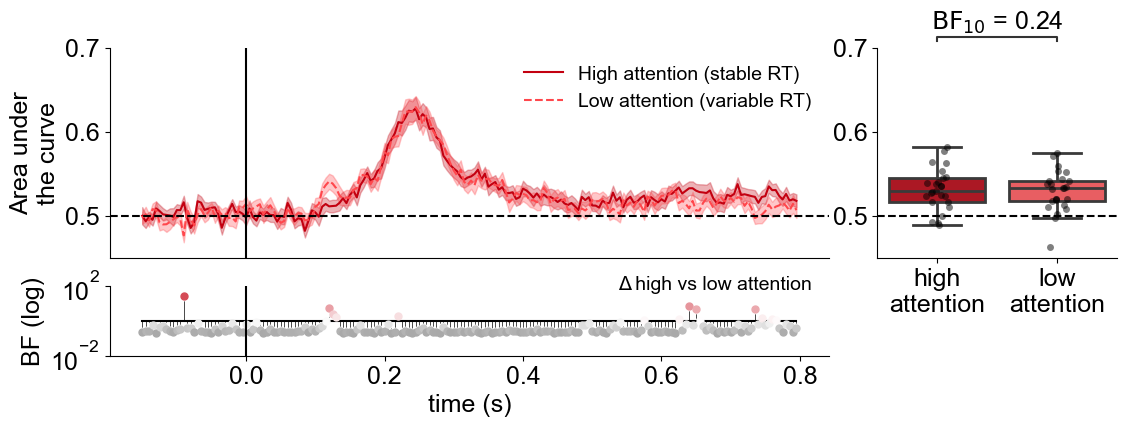

               T  dof alternative     p-val          CI95%   cohen-d   BF10  \
T-test  0.871296   24   two-sided  0.392225  [-0.01, 0.01]  0.158137  0.297   

           power  
T-test  0.118236  
high
attention
0.5547808123052953
0.027868898101374998
low
attention
0.5503547518849746
0.02697027832241345
0.297
['$\\mathrm{BF}_{10}$ = 0.30']
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

high
attention vs. low
attention: $\mathrm{BF}_{10}$ = 0.30


/Users/annacorriveau/Documents/GitHub/FluxDecoding/clean_analysis_scripts/utils/gao_functions.py:313: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


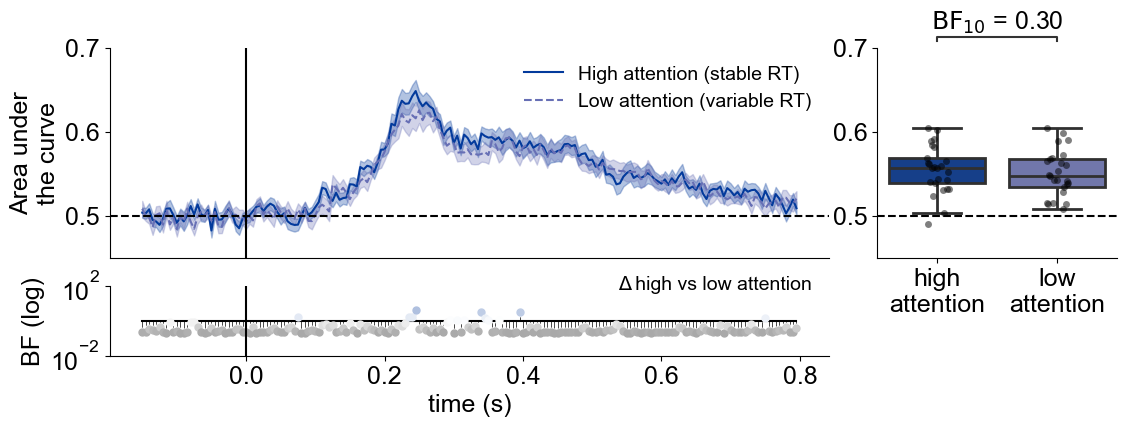

In [29]:
#### VTC split, 

in_rel_acc_df = pd.DataFrame()
out_rel_acc_df = pd.DataFrame()
in_irrel_acc_df = pd.DataFrame()
out_irrel_acc_df = pd.DataFrame()

mean_rt_in_rel = []
mean_rt_out_rel = []
mean_rt_in_irrel = []
mean_rt_out_irrel = []
# subs=['01','02','03','04','05','06','07','08','10','12','13','14',]
all_rts_in_rel = pd.DataFrame()
all_rts_out_rel = pd.DataFrame()
all_rts_in_irrel = pd.DataFrame()
all_rts_out_irrel = pd.DataFrame()

in_rel_mean = []
out_rel_mean = []
in_irrel_mean = []
out_irrel_mean = []
# subs=['01']
for s in subs:
    in_rel_acc = pd.read_csv('/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/output/timecourse_decoding/' + s + '_image_relevant_inzone_VTC_quartile_AUC_check.csv', header=None)
    in_rel_acc_df= pd.concat([in_rel_acc_df, in_rel_acc.T], axis=0)
    in_rel_mean.append(np.mean(in_rel_acc[epochs.times>0.0]))
    out_rel_acc = pd.read_csv('/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/output/timecourse_decoding/' + s + '_image_relevant_outzone_VTC_quartile_AUC_check.csv', header=None)
    out_rel_acc_df= pd.concat([out_rel_acc_df, out_rel_acc.T], axis=0)
    out_rel_mean.append(np.mean(out_rel_acc[epochs.times>0.0]))

    in_irrel_acc = pd.read_csv('/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/output/timecourse_decoding/' + s + '_image_irrelevant_inzone_VTC_quartile_AUC_check.csv', header=None)
    in_irrel_acc_df= pd.concat([in_irrel_acc_df, in_irrel_acc.T], axis=0)
    in_irrel_mean.append(np.mean(in_irrel_acc[epochs.times>0.0]))

    out_irrel_acc = pd.read_csv('/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/output/timecourse_decoding/' + s + '_image_irrelevant_outzone_VTC_quartile_AUC_check.csv', header=None)
    out_irrel_acc_df= pd.concat([out_irrel_acc_df, out_irrel_acc.T], axis=0)
    out_irrel_mean.append(np.mean(out_irrel_acc[epochs.times>0.0]))

    # # Save RTs for violin plot
    # rts_in_rel = pd.read_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_predicted_prob/' + s + '_image_relevant_inzone_VTC_quartile_raw_rts.csv', header=None)[0]
    # all_rts_in_rel = pd.concat([all_rts_in_rel, rts_in_rel], axis=0)
    # mean_rt_in_rel.append(np.nanmean(rts_in_rel))
    # rts_out_rel = pd.read_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_predicted_prob/' + s + '_image_relevant_outzone_VTC_quartile_raw_rts.csv', header=None)[0]
    # all_rts_out_rel = pd.concat([all_rts_out_rel, rts_out_rel], axis=0)
    # mean_rt_out_rel.append(np.nanmean(rts_out_rel))
    # rts_in_irrel = pd.read_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_predicted_prob/' + s + '_image_irrelevant_inzone_VTC_quartile_raw_rts.csv', header=None)[0]
    # all_rts_in_irrel = pd.concat([all_rts_in_irrel, rts_in_irrel], axis=0)
    # mean_rt_in_irrel.append(np.nanmean(rts_in_irrel))
    # rts_out_irrel = pd.read_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_predicted_prob/' + s + '_image_irrelevant_outzone_VTC_quartile_raw_rts.csv', header=None)[0]
    # all_rts_out_irrel = pd.concat([all_rts_out_irrel, rts_out_irrel], axis=0)
    # mean_rt_out_irrel.append(np.nanmean(rts_out_irrel))


mean_in_rel_acc = np.mean(in_rel_acc_df, axis=0)
mean_out_rel_acc = np.mean(out_rel_acc_df, axis=0)
mean_in_irrel_acc = np.mean(in_irrel_acc_df, axis=0)
mean_out_irrel_acc = np.mean(out_irrel_acc_df, axis=0)


SE_in_rel = stats.sem(in_rel_acc_df, axis=0)
SE_in_irrel = stats.sem(in_irrel_acc_df, axis=0)
SE_out_rel = stats.sem(out_rel_acc_df, axis=0)
SE_out_irrel = stats.sem(out_irrel_acc_df, axis=0)


bf_diff_inout = calculate_BF(in_rel_acc_df, out_rel_acc_df)

bf_diff_inoutirrel = calculate_BF(in_irrel_acc_df, out_irrel_acc_df)


plot_dict = {
    'tc1': mean_in_irrel_acc, 
    'tc1_label': "High attention (stable RT)",
    'tc2': mean_out_irrel_acc,
    'tc2_label': "Low attention (variable RT)",
    'tc1_SE': SE_in_irrel,
    'tc2_SE': SE_out_irrel,
    'tc1_color': red_color,
    'tc2_color': lightred_color,
    'tc2_linestyle':'--',
    'bar1': in_irrel_mean,
    'bar1_label': 'high\nattention',
    'bar2_label': 'low\nattention',
    'bar2': out_irrel_mean,
    'BF': bf_diff_inoutirrel,
    'BF_palette': red_palette,
    'BF_title':"\u0394 high vs low attention",
    'BF_top':2,
    'x_axis': epochs.times,
    'save_name':figdir + 'Fig3B_image_irrel_inout_onsetlocked_VTC.png'
}


make_timecourse_plot(plot_dict)



plot_dict_rel = {
    'tc1': mean_in_rel_acc, 
    'tc1_label': "High attention (stable RT)",
    'tc2': mean_out_rel_acc,
    'tc2_label': "Low attention (variable RT)",
    'tc1_SE': SE_in_rel,
    'tc2_SE': SE_out_rel,
    'tc1_color': blue_color,
    'tc2_color': lightblue_color,
    'tc2_linestyle':'--',
    'bar1': in_rel_mean,
    'bar1_label': 'high\nattention',
    'bar2_label': 'low\nattention',
    'bar2': out_rel_mean,
    'BF': bf_diff_inout,
    'BF_palette': blue_palette,
    'BF_title':"\u0394 high vs low attention",
    'BF_top':2,
    'x_axis': epochs.times,
    'save_name':figdir + 'Fig3B_image_rel_inout_onsetlocked_VTC.png'
}

make_timecourse_plot(plot_dict_rel)


/Users/annacorriveau/miniconda3/envs/gao_env/lib/python3.10/site-packages/rpy2/robjects/pandas2ri.py:56: UserWarning: DataFrame contains duplicated elements in the index, which will lead to loss of the row names in the resulting data.frame
  warnings.warn('DataFrame contains duplicated elements in the index, '


               T  dof alternative     p-val          CI95%   cohen-d   BF10  \
T-test  0.549947   24   two-sided  0.587438  [-0.01, 0.01]  0.104846  0.242   

           power  
T-test  0.079519  
high
attention
0.5305124779827335
0.021064541154599804
low
attention
0.5281307712869797
0.0233892546745793
0.242
['$\\mathrm{BF}_{10}$ = 0.24']
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

high
attention vs. low
attention: $\mathrm{BF}_{10}$ = 0.24


/Users/annacorriveau/Documents/GitHub/FluxDecoding/clean_analysis_scripts/utils/gao_functions.py:313: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


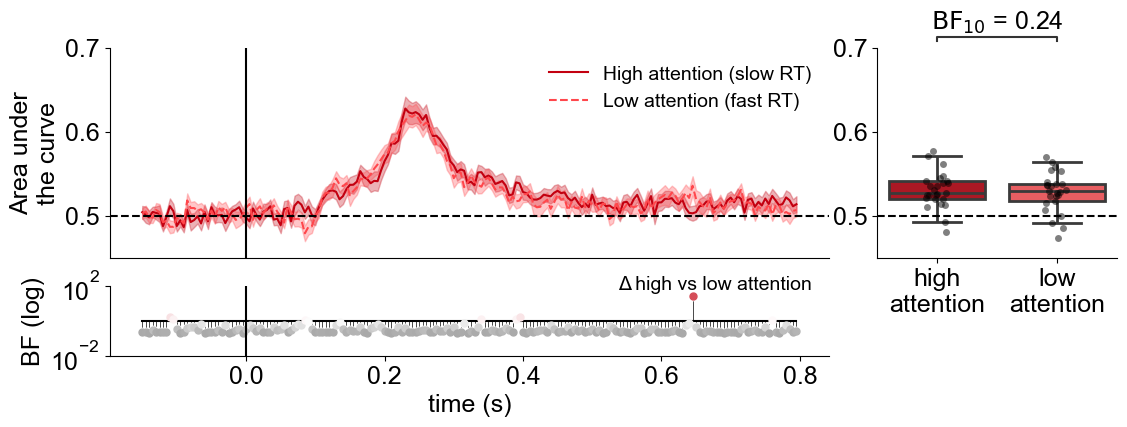

               T  dof alternative    p-val          CI95%   cohen-d   BF10  \
T-test -0.493249   24   two-sided  0.62632  [-0.01, 0.01]  0.089438  0.236   

           power  
T-test  0.071394  
high
attention
0.5531872159346239
0.027220899994615567
low
attention
0.5557521481114017
0.028950111659158142
0.236
['$\\mathrm{BF}_{10}$ = 0.24']
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

high
attention vs. low
attention: $\mathrm{BF}_{10}$ = 0.24


/Users/annacorriveau/Documents/GitHub/FluxDecoding/clean_analysis_scripts/utils/gao_functions.py:313: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


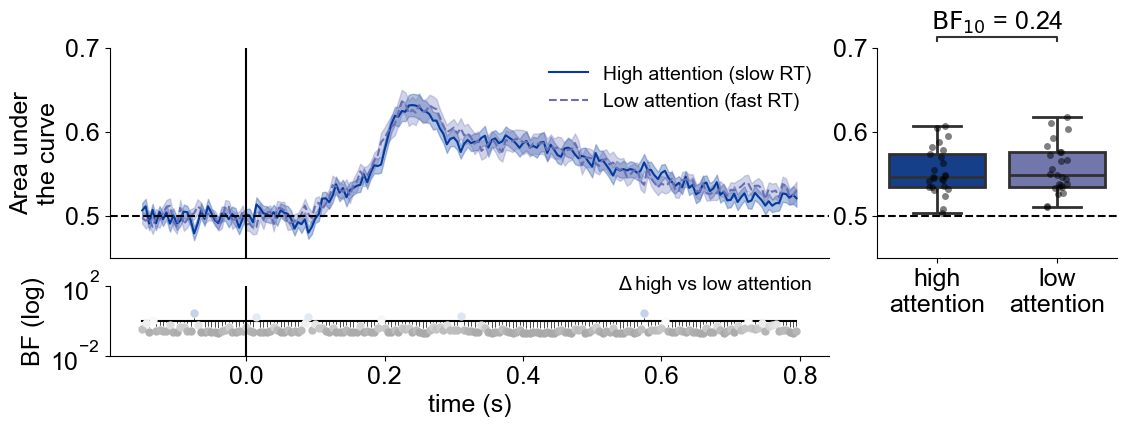

In [6]:
#### VTC split, 

in_rel_acc_df = pd.DataFrame()
out_rel_acc_df = pd.DataFrame()
in_irrel_acc_df = pd.DataFrame()
out_irrel_acc_df = pd.DataFrame()

mean_rt_in_rel = []
mean_rt_out_rel = []
mean_rt_in_irrel = []
mean_rt_out_irrel = []
# subs=['01','02','03','04','05','06','07','08','10','12','13','14',]
all_rts_in_rel = pd.DataFrame()
all_rts_out_rel = pd.DataFrame()
all_rts_in_irrel = pd.DataFrame()
all_rts_out_irrel = pd.DataFrame()

in_rel_mean = []
out_rel_mean = []
in_irrel_mean = []
out_irrel_mean = []
# subs=['01']
for s in subs:
    in_rel_acc = pd.read_csv('/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/output/timecourse_decoding/' + s + '_image_relevant_inzone_RT_quartile_AUC_check.csv', header=None)
    in_rel_acc_df= pd.concat([in_rel_acc_df, in_rel_acc.T], axis=0)
    in_rel_mean.append(np.mean(in_rel_acc[epochs.times>0.0]))
    out_rel_acc = pd.read_csv('/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/output/timecourse_decoding/' + s + '_image_relevant_outzone_RT_quartile_AUC_check.csv', header=None)
    out_rel_acc_df= pd.concat([out_rel_acc_df, out_rel_acc.T], axis=0)
    out_rel_mean.append(np.mean(out_rel_acc[epochs.times>0.0]))

    in_irrel_acc = pd.read_csv('/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/output/timecourse_decoding/' + s + '_image_irrelevant_inzone_RT_quartile_AUC_check.csv', header=None)
    in_irrel_acc_df= pd.concat([in_irrel_acc_df, in_irrel_acc.T], axis=0)
    in_irrel_mean.append(np.mean(in_irrel_acc[epochs.times>0.0]))

    out_irrel_acc = pd.read_csv('/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/output/timecourse_decoding/' + s + '_image_irrelevant_outzone_RT_quartile_AUC_check.csv', header=None)
    out_irrel_acc_df= pd.concat([out_irrel_acc_df, out_irrel_acc.T], axis=0)
    out_irrel_mean.append(np.mean(out_irrel_acc[epochs.times>0.0]))

    # # Save RTs for violin plot
    # rts_in_rel = pd.read_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_predicted_prob/' + s + '_image_relevant_inzone_VTC_quartile_raw_rts.csv', header=None)[0]
    # all_rts_in_rel = pd.concat([all_rts_in_rel, rts_in_rel], axis=0)
    # mean_rt_in_rel.append(np.nanmean(rts_in_rel))
    # rts_out_rel = pd.read_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_predicted_prob/' + s + '_image_relevant_outzone_VTC_quartile_raw_rts.csv', header=None)[0]
    # all_rts_out_rel = pd.concat([all_rts_out_rel, rts_out_rel], axis=0)
    # mean_rt_out_rel.append(np.nanmean(rts_out_rel))
    # rts_in_irrel = pd.read_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_predicted_prob/' + s + '_image_irrelevant_inzone_VTC_quartile_raw_rts.csv', header=None)[0]
    # all_rts_in_irrel = pd.concat([all_rts_in_irrel, rts_in_irrel], axis=0)
    # mean_rt_in_irrel.append(np.nanmean(rts_in_irrel))
    # rts_out_irrel = pd.read_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_predicted_prob/' + s + '_image_irrelevant_outzone_VTC_quartile_raw_rts.csv', header=None)[0]
    # all_rts_out_irrel = pd.concat([all_rts_out_irrel, rts_out_irrel], axis=0)
    # mean_rt_out_irrel.append(np.nanmean(rts_out_irrel))


mean_in_rel_acc = np.mean(in_rel_acc_df, axis=0)
mean_out_rel_acc = np.mean(out_rel_acc_df, axis=0)
mean_in_irrel_acc = np.mean(in_irrel_acc_df, axis=0)
mean_out_irrel_acc = np.mean(out_irrel_acc_df, axis=0)


SE_in_rel = stats.sem(in_rel_acc_df, axis=0)
SE_in_irrel = stats.sem(in_irrel_acc_df, axis=0)
SE_out_rel = stats.sem(out_rel_acc_df, axis=0)
SE_out_irrel = stats.sem(out_irrel_acc_df, axis=0)


bf_diff_inout = calculate_BF(in_rel_acc_df, out_rel_acc_df)

bf_diff_inoutirrel = calculate_BF(in_irrel_acc_df, out_irrel_acc_df)

plot_dict = {
    'tc1': mean_in_irrel_acc, 
    'tc1_label': "High attention (slow RT)",
    'tc2': mean_out_irrel_acc,
    'tc2_label': "Low attention (fast RT)",
    'tc1_SE': SE_in_irrel,
    'tc2_SE': SE_out_irrel,
    'tc1_color': red_color,
    'tc2_color': lightred_color,
    'tc2_linestyle':'--',
    'bar1': in_irrel_mean,
    'bar1_label': 'high\nattention',
    'bar2_label': 'low\nattention',
    'bar2': out_irrel_mean,
    'BF': bf_diff_inoutirrel,
    'BF_palette': red_palette,
    'BF_title':"\u0394 high vs low attention",
    'BF_top':2,
    'x_axis': epochs.times,
    'save_name':figdir + 'Fig3C_image_irrel_inout_onsetlocked_RT.png'
}


make_timecourse_plot(plot_dict)



plot_dict_rel = {
    'tc1': mean_in_rel_acc, 
    'tc1_label': "High attention (slow RT)",
    'tc2': mean_out_rel_acc,
    'tc2_label': "Low attention (fast RT)",
    'tc1_SE': SE_in_rel,
    'tc2_SE': SE_out_rel,
    'tc1_color': blue_color,
    'tc2_color': lightblue_color,
    'tc2_linestyle':'--',
    'bar1': in_rel_mean,
    'bar1_label': 'high\nattention',
    'bar2_label': 'low\nattention',
    'bar2': out_rel_mean,
    'BF': bf_diff_inout,
    'BF_palette': blue_palette,
    'BF_title':"\u0394 high vs low attention",
    'BF_top':2,
    'x_axis': epochs.times,
    'save_name':figdir + 'Fig3D_image_rel_inout_onsetlocked_RT.png'
}

make_timecourse_plot(plot_dict_rel)


/Users/annacorriveau/miniconda3/envs/gao_env/lib/python3.10/site-packages/rpy2/robjects/pandas2ri.py:56: UserWarning: DataFrame contains duplicated elements in the index, which will lead to loss of the row names in the resulting data.frame
  warnings.warn('DataFrame contains duplicated elements in the index, '


               T  dof alternative    p-val          CI95%   cohen-d   BF10  \
T-test -0.268486   24   two-sided  0.79062  [-0.01, 0.01]  0.075848  0.218   

           power  
T-test  0.065338  
high
attention
0.5027467115652169
0.01809280494942749
low
attention
0.5041639856657505
0.01852083838684423
0.218
['$\\mathrm{BF}_{10}$ = 0.22']
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

high
attention vs. low
attention: $\mathrm{BF}_{10}$ = 0.22


/Users/annacorriveau/Documents/GitHub/FluxDecoding/clean_analysis_scripts/utils/gao_functions.py:313: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


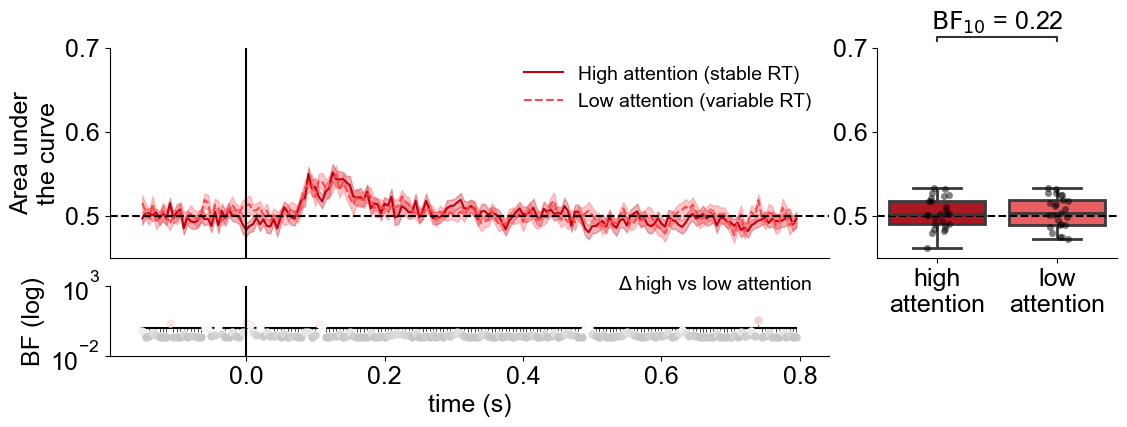

               T  dof alternative     p-val          CI95%   cohen-d   BF10  \
T-test -0.710065   24   two-sided  0.484506  [-0.01, 0.01]  0.194745  0.265   

           power  
T-test  0.154622  
high
attention
0.5105300666113552
0.013707243809976509
low
attention
0.5137709362376147
0.018543034310374587
0.265
['$\\mathrm{BF}_{10}$ = 0.27']
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

high
attention vs. low
attention: $\mathrm{BF}_{10}$ = 0.27


/Users/annacorriveau/Documents/GitHub/FluxDecoding/clean_analysis_scripts/utils/gao_functions.py:313: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


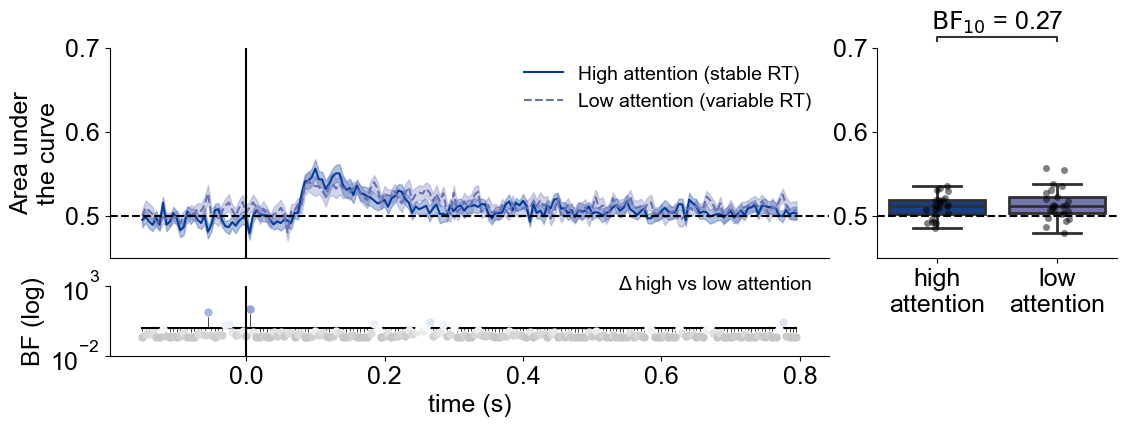

In [31]:
#### VTC split, 

in_rel_acc_df = pd.DataFrame()
out_rel_acc_df = pd.DataFrame()
in_irrel_acc_df = pd.DataFrame()
out_irrel_acc_df = pd.DataFrame()

mean_rt_in_rel = []
mean_rt_out_rel = []
mean_rt_in_irrel = []
mean_rt_out_irrel = []
# subs=['01','02','03','04','05','06','07','08','10','12','13','14',]
all_rts_in_rel = pd.DataFrame()
all_rts_out_rel = pd.DataFrame()
all_rts_in_irrel = pd.DataFrame()
all_rts_out_irrel = pd.DataFrame()

in_rel_mean = []
out_rel_mean = []
in_irrel_mean = []
out_irrel_mean = []
# subs=['01']
for s in subs:
    in_rel_acc = pd.read_csv('/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/output/timecourse_decoding/' + s + '_gabor_relevant_inzone_VTC_quartile_AUC_check.csv', header=None)
    in_rel_acc_df= pd.concat([in_rel_acc_df, in_rel_acc.T], axis=0)
    in_rel_mean.append(np.mean(in_rel_acc[epochs.times>0.0]))
    out_rel_acc = pd.read_csv('/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/output/timecourse_decoding/' + s + '_gabor_relevant_outzone_VTC_quartile_AUC_check.csv', header=None)
    out_rel_acc_df= pd.concat([out_rel_acc_df, out_rel_acc.T], axis=0)
    out_rel_mean.append(np.mean(out_rel_acc[epochs.times>0.0]))

    in_irrel_acc = pd.read_csv('/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/output/timecourse_decoding/' + s + '_gabor_irrelevant_inzone_VTC_quartile_AUC_check.csv', header=None)
    in_irrel_acc_df= pd.concat([in_irrel_acc_df, in_irrel_acc.T], axis=0)
    in_irrel_mean.append(np.mean(in_irrel_acc[epochs.times>0.0]))

    out_irrel_acc = pd.read_csv('/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/output/timecourse_decoding/' + s + '_gabor_irrelevant_outzone_VTC_quartile_AUC_check.csv', header=None)
    out_irrel_acc_df= pd.concat([out_irrel_acc_df, out_irrel_acc.T], axis=0)
    out_irrel_mean.append(np.mean(out_irrel_acc[epochs.times>0.0]))

    # # Save RTs for violin plot
    # rts_in_rel = pd.read_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_predicted_prob/' + s + '_image_relevant_inzone_VTC_quartile_raw_rts.csv', header=None)[0]
    # all_rts_in_rel = pd.concat([all_rts_in_rel, rts_in_rel], axis=0)
    # mean_rt_in_rel.append(np.nanmean(rts_in_rel))
    # rts_out_rel = pd.read_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_predicted_prob/' + s + '_image_relevant_outzone_VTC_quartile_raw_rts.csv', header=None)[0]
    # all_rts_out_rel = pd.concat([all_rts_out_rel, rts_out_rel], axis=0)
    # mean_rt_out_rel.append(np.nanmean(rts_out_rel))
    # rts_in_irrel = pd.read_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_predicted_prob/' + s + '_image_irrelevant_inzone_VTC_quartile_raw_rts.csv', header=None)[0]
    # all_rts_in_irrel = pd.concat([all_rts_in_irrel, rts_in_irrel], axis=0)
    # mean_rt_in_irrel.append(np.nanmean(rts_in_irrel))
    # rts_out_irrel = pd.read_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_predicted_prob/' + s + '_image_irrelevant_outzone_VTC_quartile_raw_rts.csv', header=None)[0]
    # all_rts_out_irrel = pd.concat([all_rts_out_irrel, rts_out_irrel], axis=0)
    # mean_rt_out_irrel.append(np.nanmean(rts_out_irrel))


mean_in_rel_acc = np.mean(in_rel_acc_df, axis=0)
mean_out_rel_acc = np.mean(out_rel_acc_df, axis=0)
mean_in_irrel_acc = np.mean(in_irrel_acc_df, axis=0)
mean_out_irrel_acc = np.mean(out_irrel_acc_df, axis=0)


SE_in_rel = stats.sem(in_rel_acc_df, axis=0)
SE_in_irrel = stats.sem(in_irrel_acc_df, axis=0)
SE_out_rel = stats.sem(out_rel_acc_df, axis=0)
SE_out_irrel = stats.sem(out_irrel_acc_df, axis=0)


bf_diff_inout = calculate_BF(in_rel_acc_df, out_rel_acc_df)

bf_diff_inoutirrel = calculate_BF(in_irrel_acc_df, out_irrel_acc_df)


#### PLOT FOR  BLRB
# fig = plt.figure(figsize=(18, 6))

# gs = fig.add_gridspec(
#     nrows=3,
#     ncols=5,
#     width_ratios=[7, 1, 1, 1, 1],
#     height_ratios=[3, 1, 1],
#     wspace=0.1,
#     hspace=0.4
# )

# # Left column
# ax_dec = fig.add_subplot(gs[0, 0])
# ax_bf1 = fig.add_subplot(gs[1, 0])
# ax_bf2 = fig.add_subplot(gs[2, 0])

# # Right side of decoding plot
# ax_in_rel = fig.add_subplot(gs[0, 1], sharey=ax_dec)
# ax_out_rel = fig.add_subplot(gs[0, 2], sharey=ax_dec)
# ax_in_irrel = fig.add_subplot(gs[0, 3], sharey=ax_dec)
# ax_out_irrel = fig.add_subplot(gs[0, 4], sharey=ax_dec)


plot_dict = {
    'tc1': mean_in_irrel_acc, 
    'tc1_label': "High attention (stable RT)",
    'tc2': mean_out_irrel_acc,
    'tc2_label': "Low attention (variable RT)",
    'tc1_SE': SE_in_irrel,
    'tc2_SE': SE_out_irrel,
    'tc1_color': red_color,
    'tc2_color': lightred_color,
    'tc2_linestyle':'--',
    'bar1': in_irrel_mean,
    'bar1_label': 'high\nattention',
    'bar2_label': 'low\nattention',
    'bar2': out_irrel_mean,
    'BF': bf_diff_inoutirrel,
    'BF_palette': red_palette,
    'BF_title':"\u0394 high vs low attention",
    'BF_top':3,
    'x_axis': epochs.times,
    'save_name':figdir + 'FigSupp_gabor_irrel_inout_onsetlocked_VTC.png'
}


make_timecourse_plot(plot_dict)



plot_dict_rel = {
    'tc1': mean_in_rel_acc, 
    'tc1_label': "High attention (stable RT)",
    'tc2': mean_out_rel_acc,
    'tc2_label': "Low attention (variable RT)",
    'tc1_SE': SE_in_rel,
    'tc2_SE': SE_out_rel,
    'tc1_color': blue_color,
    'tc2_color': lightblue_color,
    'tc2_linestyle':'--',
    'bar1': in_rel_mean,
    'bar1_label': 'high\nattention',
    'bar2_label': 'low\nattention',
    'bar2': out_rel_mean,
    'BF': bf_diff_inout,
    'BF_palette': blue_palette,
    'BF_title':"\u0394 high vs low attention",
    'BF_top':3,
    'x_axis': epochs.times,
    'save_name':figdir + 'FigSupp_gabor_rel_inout_onsetlocked_VTC.png'
}

make_timecourse_plot(plot_dict_rel)


/Users/annacorriveau/miniconda3/envs/gao_env/lib/python3.10/site-packages/rpy2/robjects/pandas2ri.py:56: UserWarning: DataFrame contains duplicated elements in the index, which will lead to loss of the row names in the resulting data.frame
  warnings.warn('DataFrame contains duplicated elements in the index, '


               T  dof alternative     p-val         CI95%   cohen-d   BF10  \
T-test -1.299568   24   two-sided  0.206094  [-0.01, 0.0]  0.309889  0.446   

           power  
T-test  0.318631  
high
attention
0.5039815706558167
0.013642505924218496
low
attention
0.5095285432005554
0.02071380158372606
0.446
['$\\mathrm{BF}_{10}$ = 0.45']
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

high
attention vs. low
attention: $\mathrm{BF}_{10}$ = 0.45


/Users/annacorriveau/Documents/GitHub/FluxDecoding/clean_analysis_scripts/utils/gao_functions.py:313: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


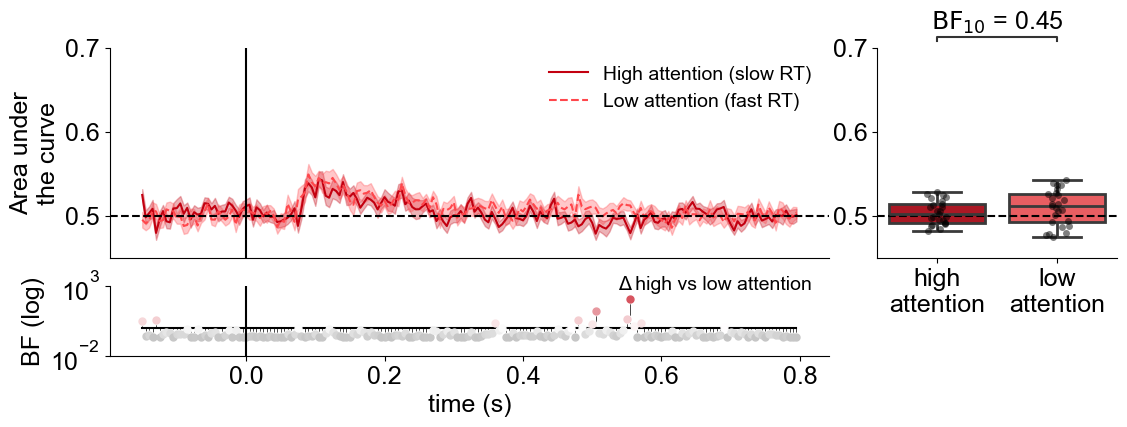

               T  dof alternative    p-val          CI95%   cohen-d   BF10  \
T-test  0.246972   24   two-sided  0.80703  [-0.01, 0.01]  0.072171  0.217   

           power  
T-test  0.063875  
high
attention
0.5135311666962273
0.013875210913156532
low
attention
0.512290871941487
0.0193529668531796
0.217
['$\\mathrm{BF}_{10}$ = 0.22']
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

high
attention vs. low
attention: $\mathrm{BF}_{10}$ = 0.22


/Users/annacorriveau/Documents/GitHub/FluxDecoding/clean_analysis_scripts/utils/gao_functions.py:313: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


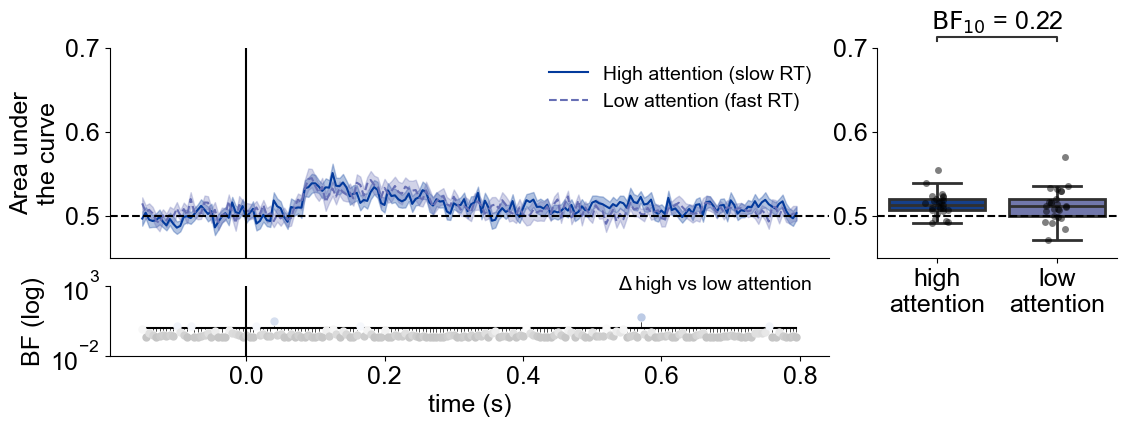

In [7]:
#### VTC split, 

in_rel_acc_df = pd.DataFrame()
out_rel_acc_df = pd.DataFrame()
in_irrel_acc_df = pd.DataFrame()
out_irrel_acc_df = pd.DataFrame()

mean_rt_in_rel = []
mean_rt_out_rel = []
mean_rt_in_irrel = []
mean_rt_out_irrel = []
# subs=['01','02','03','04','05','06','07','08','10','12','13','14',]
all_rts_in_rel = pd.DataFrame()
all_rts_out_rel = pd.DataFrame()
all_rts_in_irrel = pd.DataFrame()
all_rts_out_irrel = pd.DataFrame()

in_rel_mean = []
out_rel_mean = []
in_irrel_mean = []
out_irrel_mean = []
# subs=['01']
for s in subs:
    in_rel_acc = pd.read_csv('/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/output/timecourse_decoding/' + s + '_gabor_relevant_inzone_RT_quartile_AUC_check.csv', header=None)
    in_rel_acc_df= pd.concat([in_rel_acc_df, in_rel_acc.T], axis=0)
    in_rel_mean.append(np.mean(in_rel_acc[epochs.times>0.0]))
    out_rel_acc = pd.read_csv('/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/output/timecourse_decoding/' + s + '_gabor_relevant_outzone_RT_quartile_AUC_check.csv', header=None)
    out_rel_acc_df= pd.concat([out_rel_acc_df, out_rel_acc.T], axis=0)
    out_rel_mean.append(np.mean(out_rel_acc[epochs.times>0.0]))

    in_irrel_acc = pd.read_csv('/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/output/timecourse_decoding/' + s + '_gabor_irrelevant_inzone_RT_quartile_AUC_check.csv', header=None)
    in_irrel_acc_df= pd.concat([in_irrel_acc_df, in_irrel_acc.T], axis=0)
    in_irrel_mean.append(np.mean(in_irrel_acc[epochs.times>0.0]))

    out_irrel_acc = pd.read_csv('/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/output/timecourse_decoding/' + s + '_gabor_irrelevant_outzone_RT_quartile_AUC_check.csv', header=None)
    out_irrel_acc_df= pd.concat([out_irrel_acc_df, out_irrel_acc.T], axis=0)
    out_irrel_mean.append(np.mean(out_irrel_acc[epochs.times>0.0]))


mean_in_rel_acc = np.mean(in_rel_acc_df, axis=0)
mean_out_rel_acc = np.mean(out_rel_acc_df, axis=0)
mean_in_irrel_acc = np.mean(in_irrel_acc_df, axis=0)
mean_out_irrel_acc = np.mean(out_irrel_acc_df, axis=0)


SE_in_rel = stats.sem(in_rel_acc_df, axis=0)
SE_in_irrel = stats.sem(in_irrel_acc_df, axis=0)
SE_out_rel = stats.sem(out_rel_acc_df, axis=0)
SE_out_irrel = stats.sem(out_irrel_acc_df, axis=0)


bf_diff_inout = calculate_BF(in_rel_acc_df, out_rel_acc_df)

bf_diff_inoutirrel = calculate_BF(in_irrel_acc_df, out_irrel_acc_df)



plot_dict = {
    'tc1': mean_in_irrel_acc, 
    'tc1_label': "High attention (slow RT)",
    'tc2': mean_out_irrel_acc,
    'tc2_label': "Low attention (fast RT)",
    'tc1_SE': SE_in_irrel,
    'tc2_SE': SE_out_irrel,
    'tc1_color': red_color,
    'tc2_color': lightred_color,
    'tc2_linestyle':'--',
    'bar1': in_irrel_mean,
    'bar1_label': 'high\nattention',
    'bar2_label': 'low\nattention',
    'bar2': out_irrel_mean,
    'BF': bf_diff_inoutirrel,
    'BF_palette': red_palette,
    'BF_title':"\u0394 high vs low attention",
    'BF_top':3,
    'x_axis': epochs.times,
    'save_name':figdir + 'FigSupp_gabor_irrel_inout_onsetlocked_RT.png'
}


make_timecourse_plot(plot_dict)



plot_dict_rel = {
    'tc1': mean_in_rel_acc, 
    'tc1_label': "High attention (slow RT)",
    'tc2': mean_out_rel_acc,
    'tc2_label': "Low attention (fast RT)",
    'tc1_SE': SE_in_rel,
    'tc2_SE': SE_out_rel,
    'tc1_color': blue_color,
    'tc2_color': lightblue_color,
    'tc2_linestyle':'--',
    'bar1': in_rel_mean,
    'bar1_label': 'high\nattention',
    'bar2_label': 'low\nattention',
    'bar2': out_rel_mean,
    'BF': bf_diff_inout,
    'BF_palette': blue_palette,
    'BF_title':"\u0394 high vs low attention",
    'BF_top':3,
    'x_axis': epochs.times,
    'save_name':figdir + 'FigSupp_gabor_rel_inout_onsetlocked_RT.png'
}

make_timecourse_plot(plot_dict_rel)


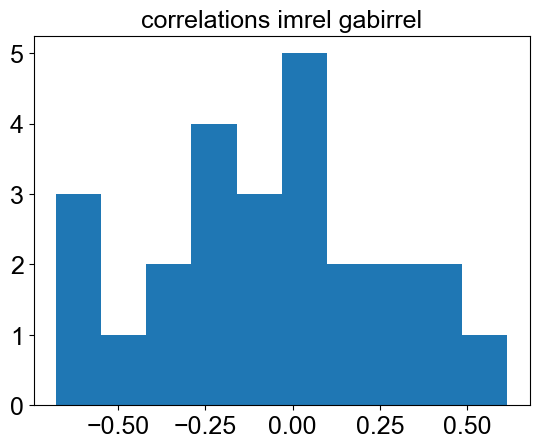

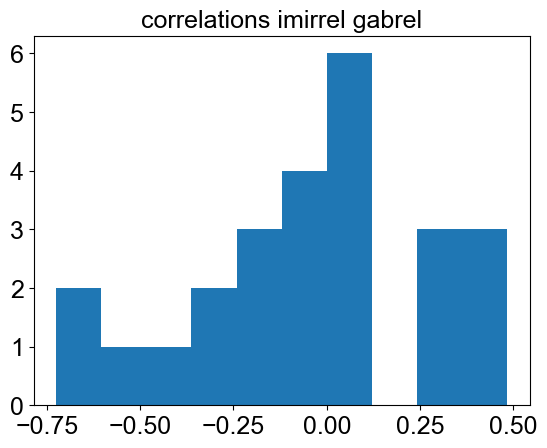

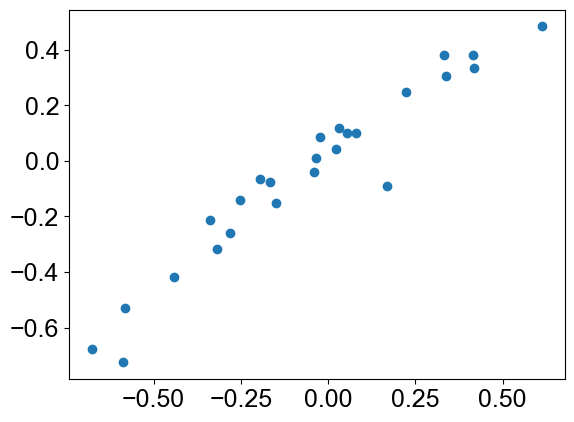

<function matplotlib.pyplot.show(close=None, block=None)>

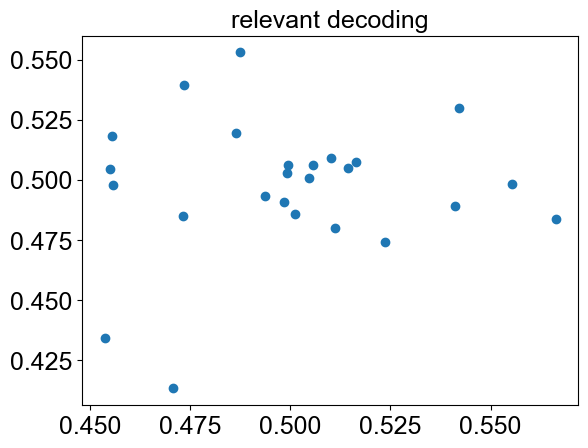

In [29]:
# Are trial-wise predictions correlated (either positively or negatively)?
corr_imrel_gabirrel = []
corr_imirrel_gabrel = []

mean_imrel = []
mean_gabrel = []
mean_imirrel = []
mean_gabirrel = []

for s in subs:
    im_rel = pd.read_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/timecourse_decoding/' + s + '_image_relevant_pproba_EEG.csv', header=None)
    im_rel_trial = im_rel.iloc[:, epochs.times>0]
    mean_imrel.append(np.mean(np.mean(im_rel_trial, axis=1), axis=0))
    gab_irrel = pd.read_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/timecourse_decoding/' + s + '_gabor_irrelevant_pproba_EEG.csv', header=None)
    gab_irrel_trial = gab_irrel.iloc[:, epochs.times>0]
    mean_gabirrel.append(np.mean(np.mean(gab_irrel_trial, axis=1), axis=0))

    mean_im_rel = np.mean(im_rel_trial, axis=1)
    mean_gab_irrel = np.mean(gab_irrel_trial, axis=1)

    corr_imrel_gabirrel.append(pg.corr(mean_im_rel, mean_gab_irrel).r.values[0])


    im_irrel = pd.read_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/timecourse_decoding/' + s + '_image_irrelevant_pproba_EEG.csv', header=None)
    im_irrel_trial = im_irrel.iloc[:, epochs.times>0]
    mean_imirrel.append(np.mean(np.mean(im_irrel_trial, axis=1), axis=0))

    gab_rel = pd.read_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/timecourse_decoding/' + s + '_gabor_relevant_pproba_EEG.csv', header=None)
    gab_rel_trial = gab_rel.iloc[:, epochs.times>0]
    mean_gabrel.append(np.mean(np.mean(gab_rel_trial, axis=1), axis=0))

    mean_im_irrel = np.mean(im_irrel_trial, axis=1)
    mean_gab_rel = np.mean(gab_rel_trial, axis=1)

    corr_imirrel_gabrel.append(pg.corr(mean_im_irrel, mean_gab_rel).r.values[0])


plt.hist(corr_imrel_gabirrel)
plt.title('correlations imrel gabirrel')
plt.show()

plt.hist(corr_imirrel_gabrel)
plt.title('correlations imirrel gabrel')
plt.show()

pg.corr(corr_imrel_gabirrel, corr_imirrel_gabrel)

plt.scatter(corr_imrel_gabirrel, corr_imirrel_gabrel)
plt.show()

plt.scatter(mean_imrel, mean_gabirrel)
plt.title('relevant decoding')
plt.show

              T  dof alternative     p-val         CI95%   cohen-d   BF10  \
T-test -0.82221   24   two-sided  0.419051  [-0.2, 0.08]  0.164442  0.286   

          power  
T-test  0.12393  
               T  dof alternative     p-val          CI95%   cohen-d   BF10  \
T-test -0.693647   24   two-sided  0.494563  [-0.18, 0.09]  0.138729  0.262   

         power  
T-test  0.1022  
-0.055661799679336904
0.3316500408539169
-0.04475656422432667
0.316099648236455


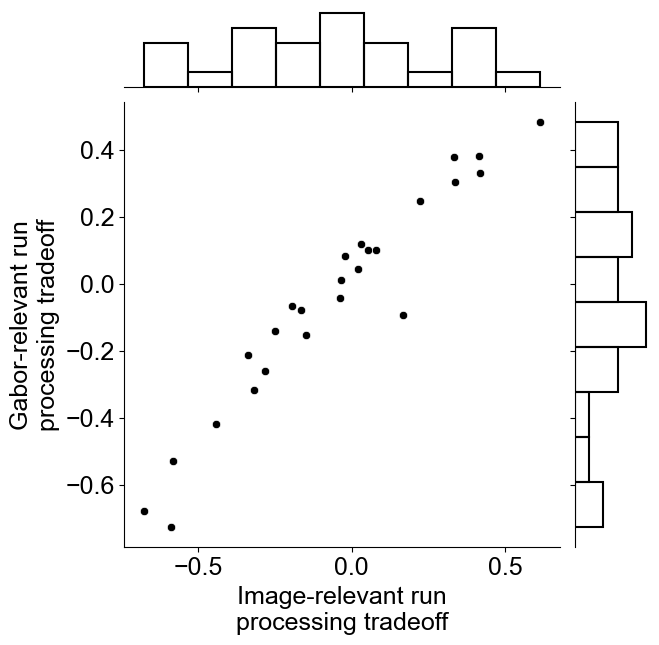

          n         r         CI95%         p-val       BF10  power
pearson  25  0.964197  [0.92, 0.98]  9.387902e-15  3.786e+11    1.0


In [49]:
print(pg.ttest(corr_imrel_gabirrel, 0))
print(pg.ttest(corr_imirrel_gabrel, 0))
print(np.mean(corr_imrel_gabirrel))
print(np.std(corr_imrel_gabirrel))
print(np.mean(corr_imirrel_gabrel))
print(np.std(corr_imirrel_gabrel))

# fig, ax=plt.subplots()
fig = sns.jointplot(x=corr_imrel_gabirrel, y=corr_imirrel_gabrel, marginal_kws=dict(bins=9, fill=False), color='k')
fig.set_axis_labels('Image-relevant run\nprocessing tradeoff', "Gabor-relevant run\nprocessing tradeoff", fontsize=18)
plt.savefig(figdir + 'Processing_tradeoff.png', bbox_inches='tight')
plt.show()
print(pg.corr(corr_imrel_gabirrel, corr_imirrel_gabrel))


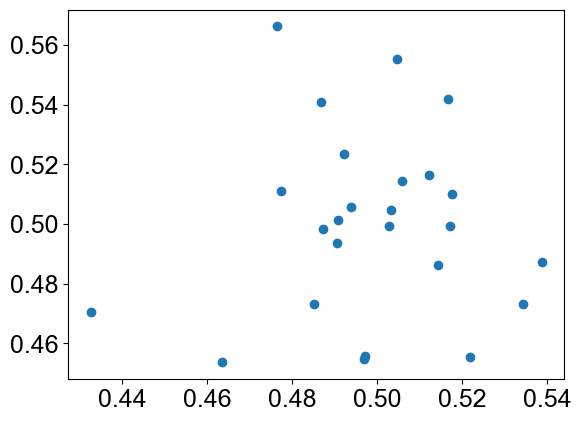

In [35]:
plt.scatter(mean_gabrel, mean_imrel)